# Prediction of Solar Energy Potential Based on Weather and Location Data

## Project Descrption

- The anticipated surge in electricity demand, projected to increase by approximately 30% by 2035 according to the US Department of Energy, necessitates substantial investments in sustainable renewable energy resources to meet this growth.

- Addressing this challenge could be facilitated through the adoption of solar energy, as suggested by the same report. It indicates the potential for solar energy to contribute up to 40% of the country's electricity supply by 2035, a significant increase from its current contribution of 3%.

- In order to enhance the solar energy infrastructure, identifying new locations with the utmost potential for consistent solar electricity generation becomes crucial. Utilizing predictive modeling, based on diverse features, can aid in pinpointing such sites.

## Goal

Analyzing the potential solar energy power (Watts) that can be generated based on the weather and location characteristics at a specific time.

## Reference and Source

- Paper Reference Source :

    Pasion C, Wagner T, Koschnick C, Schuldt S, Williams J, Hallinan K. Machine Learning Modeling of Horizontal Photovoltaics Using Weather and Location Data. Energies. 2020; 13(10):2570. https://doi.org/10.3390/en13102570

- Dataset Source :

    https://www.kaggle.com/datasets/saurabhshahane/northern-hemisphere-horizontal-photovoltaic

### Import Libraries and Settings

In [48]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', None)
# pd.set_option('display.float_format', '{:.15f}'.format)
pd.reset_option('display.float_format')

# Requirements
print('numpy version : ',np.__version__)
print('pandas version : ',pd.__version__)
print('seaborn version : ',sns.__version__)

numpy version :  1.26.4
pandas version :  2.2.1
seaborn version :  0.13.2


#### Load Dataset (Jupyter Notebook)

In [49]:
df = pd.read_csv('Pasion et al dataset.csv')

#### Load Dataset (Google Colab)

In [50]:
# from google.colab import drive
# drive.mount('/content/drive')

In [51]:
# df = pd.read_csv('/content/drive/MyDrive/Personal Projects/Prediction of Solar Energy Potential Based on Weather and Location Data/Pasion et al dataset.csv')

# Initial Data Understanding and Pre-Processing

In [52]:
# Checking basic data information
def check_data_information(df, cols):
    """
    This function provides detailed information about each column in a dataframe, including:
    - Data type of the column
    - Number of missing (null) values
    - Percentage of missing values
    - Total number of duplicated rows in the dataframe (not column-specific)
    - Number of unique values in the column
    - A sample of up to 5 unique values from the column

    Parameters:
    df (pd.DataFrame): The dataframe you want to check.
    cols (list): List of column names to check the information from.

    Returns:
    pd.DataFrame: A dataframe with detailed information for each column.
    """
    list_item = []
    for col in cols:
        list_item.append([col,                             # The column name
                          df[col].dtype,                   # The data type of the column
                          df[col].isna().sum(),            # The count of null values in the column
                          round(100 * df[col].isna().sum() / len(df[col]), 2),  # The percentage of null values
                          df.duplicated().sum(),           # The count of duplicated rows in the entire dataframe
                          df[col].nunique(),               # The count of unique values in the column
                          df[col].unique()[:5]])           # A sample of the first 5 unique values in the column

    desc_df = pd.DataFrame(data=list_item, columns='Feature, Data Type, Null Values, Null Percentage, Duplicated Values, Unique Values, Unique Sample'.split(","))
    return desc_df

columns_to_check = df.columns
check_data_information(df, columns_to_check)

,Feature,Data Type,Null Values,Null Percentage,Duplicated Values,Unique Values,Unique Sample
0,Location,object,0,0.0,0,12,"[Camp Murray, Grissom, Hill Weber, JDMT, Kahului]"
1,Date,int64,0,0.0,0,500,"[20171203, 20171204, 20171205, 20171206, 20171207]"
2,Time,int64,0,0.0,0,24,"[1145, 1315, 1330, 1230, 1415]"
3,Latitude,float64,0,0.0,0,12,"[47.11, 40.67, 41.15, 26.98, 20.89]"
4,Longitude,float64,0,0.0,0,12,"[-122.57, -86.15, -111.99, -80.11, -156.44]"
5,Altitude,int64,0,0.0,0,11,"[84, 239, 1370, 2, 1043]"
6,YRMODAHRMI,float64,0,0.0,0,18,"[201712000000.0, 201801000000.0, 201802000000.0, 201803000000.0, 201804000000.0]"
7,Month,int64,0,0.0,0,12,"[12, 1, 2, 3, 4]"
8,Hour,int64,0,0.0,0,6,"[11, 13, 12, 14, 15]"
9,Season,object,0,0.0,0,4,"[Winter, Spring, Summer, Fall]"


There are no missing or duplicated values in this dataset

## Feature Description (From Paper)

- **`Cloud Ceiling`:**
  - Definition: The presence of clouds above a panel scatters solar irradiance, decreasing the amount of irradiation received.
  - Measurement: Cloud ceiling is measured at the altitude where at least 5/8ths of the sky above the weather station is covered by clouds [17–25].

- **`Latitude`:**
  - Definition: Latitude of each location dictates the sun deflection angle, impacting the amount of sunlight received by the panel.
  - References: [12, 21–23, 25, 26].

- **`Month`:**
  - Definition: The time of year at a location determines the sun's rise, set, and its height in the sky.
  - References: [13, 21].

- **`Hour`:**
  - Definition: The time of day determines the sun's position, influencing the amount of sunlight received.
  - References: [21].

- **`Humidity`:**
  - Definition: Water affects incoming sunlight through refraction, diffraction, and reflection. Humidity indirectly affects dust build-up on panels.
  - Additional Info: Dew formation on the panel surface may enhance performance under humid conditions.
  - References: [27, 28].

- **`Temperature`:**
  - Definition: Solar panel efficiency generally decreases with increasing panel temperature.
  - Additional Info: Temperature as an explanatory variable enhances power output predictability.
  - References: [29, 30, 12, 13, 31–33].

- **`Wind Speed`:**
  - Definition: Wind speed may affect panel temperature and clean dust off the panel surface or stir up dust, influencing irradiance reaching the panel.
  - References: [34, 35, 36].

- **`Visibility`:**
  - Definition: Measurement of the distance at which light can be seen and identified.
  - Impact: Affects irradiation reaching the panel; low visibility during daylight hours may negatively impact power output.
  - References: [37].

- **`Pressure`:**
  - Definition: Pressure may indicate weather occurrences, such as storms, potentially affecting power output predictability.
  - Note: This variable has not been extensively explored in solar panel power output literature.
  - References: [38].

- **`Altitude`:**
  - Definition: Locations at higher altitudes have less atmosphere for the sun to travel through, resulting in higher irradiation.
  - Impact: Higher altitudes above sea level receive higher levels of irradiation.


## Target Description (From Paper)

**`PolyPwr`** means the amount of power output (Watts) recorded from Raspberry Pi computer system in polycrystalline PV panels at 15-min time intervals

In [53]:
# Checking the data samples
df.sample(20)

,Location,Date,Time,Latitude,Longitude,Altitude,YRMODAHRMI,Month,Hour,Season,Humidity,AmbientTemp,PolyPwr,Wind.Speed,Visibility,Pressure,Cloud.Ceiling
12151,MNANG,20180919,1200,44.89,-93.20,246,2.018090e+11,9,12,Fall,93.20068,16.81190,2.78455,13,8.0,985.2,5
8235,Malmstrom,20180324,1130,47.52,-111.18,1043,2.018030e+11,3,11,Spring,50.16479,12.25739,2.63879,6,7.0,883.8,70
20518,USAFA,20180711,1300,38.95,-104.83,1947,2.018070e+11,7,13,Summer,12.12769,48.30330,18.23362,6,10.0,802.0,722
20937,USAFA,20180905,1400,38.95,-104.83,1947,2.018090e+11,9,14,Fall,73.82812,21.91780,5.14157,7,10.0,807.3,70
12744,Offutt,20180712,1300,41.13,-95.75,380,2.018070e+11,7,13,Summer,42.35840,40.03769,21.80444,13,10.0,979.4,722
7060,Kahului,20180120,1300,20.89,-156.44,2,2.018010e+11,1,13,Winter,64.01367,28.97743,3.78170,16,10.0,1013.1,722
9871,March AFB,20171023,1400,33.90,-117.26,458,2.017100e+11,10,14,Fall,4.05273,41.28647,12.83469,9,10.0,964.0,722
2311,Grissom,20180811,1500,40.67,-86.15,239,2.018080e+11,8,15,Summer,38.24463,38.74863,19.00943,6,10.0,986.8,722
5733,JDMT,20171006,1500,26.98,-80.11,2,2.017100e+11,10,15,Fall,48.01636,40.68977,16.84454,14,10.0,1013.2,210
1822,Grissom,20180605,1200,40.67,-86.15,239,2.018060e+11,6,12,Summer,32.01294,33.52692,19.02682,16,10.0,981.2,722


Just from these information, there are some useful insight to this data that understanding it could make it easier for further analysis and feature transformation, they are :

- Date feature have the wrong format should be in datetime instead of integer.

- Time feature values are wrong because it's written in the format of hour:minute but because of it's data time is integer, it became hourminute (ex : 10:00 -> 1000).

- The hour feature only have 6 distinct values because the data is recorded during the peak hour only (11, 13, 12, 14, 15).

- Latitude and Longitude are useful if we want to make it into geographical plot in Tableau or similar tools, but in here it's already represented by Location, though i read that we could also do geospatial analysis and mapping in python using libraries like Arcpy, Geopandas, Geoplot, etc combined with specific tools/software but i haven't learn details of it right now probably later in the future.

- YRMODAHRMI (year, month, day, hour, minute) is actually similar to Date, but it has more detailed date information, probably will check what the values are like since it has so many digits.

- There are also separate feature for Month and Hour, we could use this and even though we could extract similar information in YRMODAHRMI feature.

- As for categorical feature like Location and Season potentially could be encoded by one-hot enxoding.

- Several features scientifically could have high correlation to each other for example Altitude with Pressure and Humidity, but we will check details of this later in bivariate analysis.

- PolyPwr is the target variable, we could move it to the last order in dataframe (personal preference).

**! Update on the values of YRMODAHRMI feature** :

- It does not actually represent year, month, day, hour, minute completely. This was investigated using the pd.set_option('display.float_format', '{:.15f}'.format) to set the values in pandas so that we can see all the digits (we could also see it with just the code down below) but here is the example value of the YRMODAHRMI feature 201712000000.000000000000000.

- It can be seen that it only gives you the information of year and month only, so this feature will not be used later.

In [54]:
# Checking on YRMODAHRMI feature values
df['YRMODAHRMI'][0]

201712000000.0

Since the YRMODAHRMI feature doesn't contain the complete values, we can just take the complete values from combining Date and Time column and transform it to datetime datatype and restructure the entire datteime components for this dataset.

In [55]:
# Datetime components processing
df['Datetime'] = df['Date'].astype('str') + ' ' + df['Time'].astype('str')
df['Datetime'] = pd.to_datetime(df['Datetime'], format='%Y%m%d %H%M')

# Extract Date and Time from Datetime
df['Date'] = df['Datetime'].dt.date
df['Time'] = df['Datetime'].dt.strftime('%H:%M')

# Extract datetime components from year until hour
df['Year'] = df['Datetime'].dt.year
df['Month'] = df['Datetime'].dt.month
df['Day'] = df['Datetime'].dt.day
df['Hour'] = df['Datetime'].dt.hour

# Drop the YRMODAHRMI column
df = df.drop(columns=['YRMODAHRMI'])

In [56]:
# Re-arrange the columns
# Group date components together in chronological order and put PolyPwr at the end
date_cols = ['Datetime', 'Date', 'Time', 'Year', 'Month', 'Day', 'Hour']
location_cols = ['Location', 'Latitude', 'Longitude', 'Altitude']
weather_cols = ['Season', 'Humidity', 'AmbientTemp', 'Wind.Speed', 'Visibility', 'Pressure', 'Cloud.Ceiling']
target_col = ['PolyPwr']

# Create the final column order
arrange_col = date_cols + location_cols + weather_cols + target_col
df = df[arrange_col]

We can also try to fix the inconsistent formatting on the columns, but probably keeping it like this is just fine.

In [57]:
# # # Initial data transformation :  converting column name to lowercase
# df.columns = df.columns.str.lower()

# # Combine columns with dot separator (like Wind.Speed) and handle camelCase (like AmbientTemp)
# for col in df.columns.to_list():
#     # Handle dot separator case
#     if '.' in col:
#         new_col = '_'.join(col.split('.'))
#         df.rename(columns={col: new_col}, inplace=True)
        
#     # Handle camelCase (words with capital letters in the middle)
#     elif any(c.isupper() for c in col[1:]):
#         # Find all capital letters and add underscore before them
#         new_col = col[0]
#         for c in col[1:]:
#             if c.isupper():
#                 new_col += '_' + c.lower()
#             else:
#                 new_col += c
#         df.rename(columns={col: new_col.lower()}, inplace=True)

Now let's try to understand the location columns in this dataset

In [58]:
# Get the geo components for different locations
df[location_cols].value_counts()

Location     Latitude  Longitude  Altitude
Travis       38.16     -121.56    1           2746
Peterson     38.82     -104.71    1879        2640
USAFA        38.95     -104.83    1947        2573
Hill Weber   41.15     -111.99    1370        2384
March AFB    33.90     -117.26    458         2204
JDMT         26.98     -80.11     2           1779
Malmstrom    47.52     -111.18    1043        1517
Grissom      40.67     -86.15     239         1487
Camp Murray  47.11     -122.57    84          1113
Kahului      20.89     -156.44    2            941
Offutt       41.13     -95.75     380          881
MNANG        44.89     -93.20     246          780
Name: count, dtype: int64

There are indeed only 12 locations for the photovoltaic site in this dataset.

Average Solar Power by Location and Hour:
      Location  Hour    PolyPwr
22        JDMT    14  21.040531
21        JDMT    13  20.725236
20        JDMT    12  20.461270
19        JDMT    11  18.471420
26     Kahului    12  17.529915
28     Kahului    14  16.924876
27     Kahului    13  16.811872
16  Hill Weber    14  16.609368
23        JDMT    15  16.364104
15  Hill Weber    13  16.251637
52      Offutt    14  16.133708
45   March AFB    13  15.856107
25     Kahului    11  15.589097
18        JDMT    10  15.433431
53      Offutt    15  15.430490


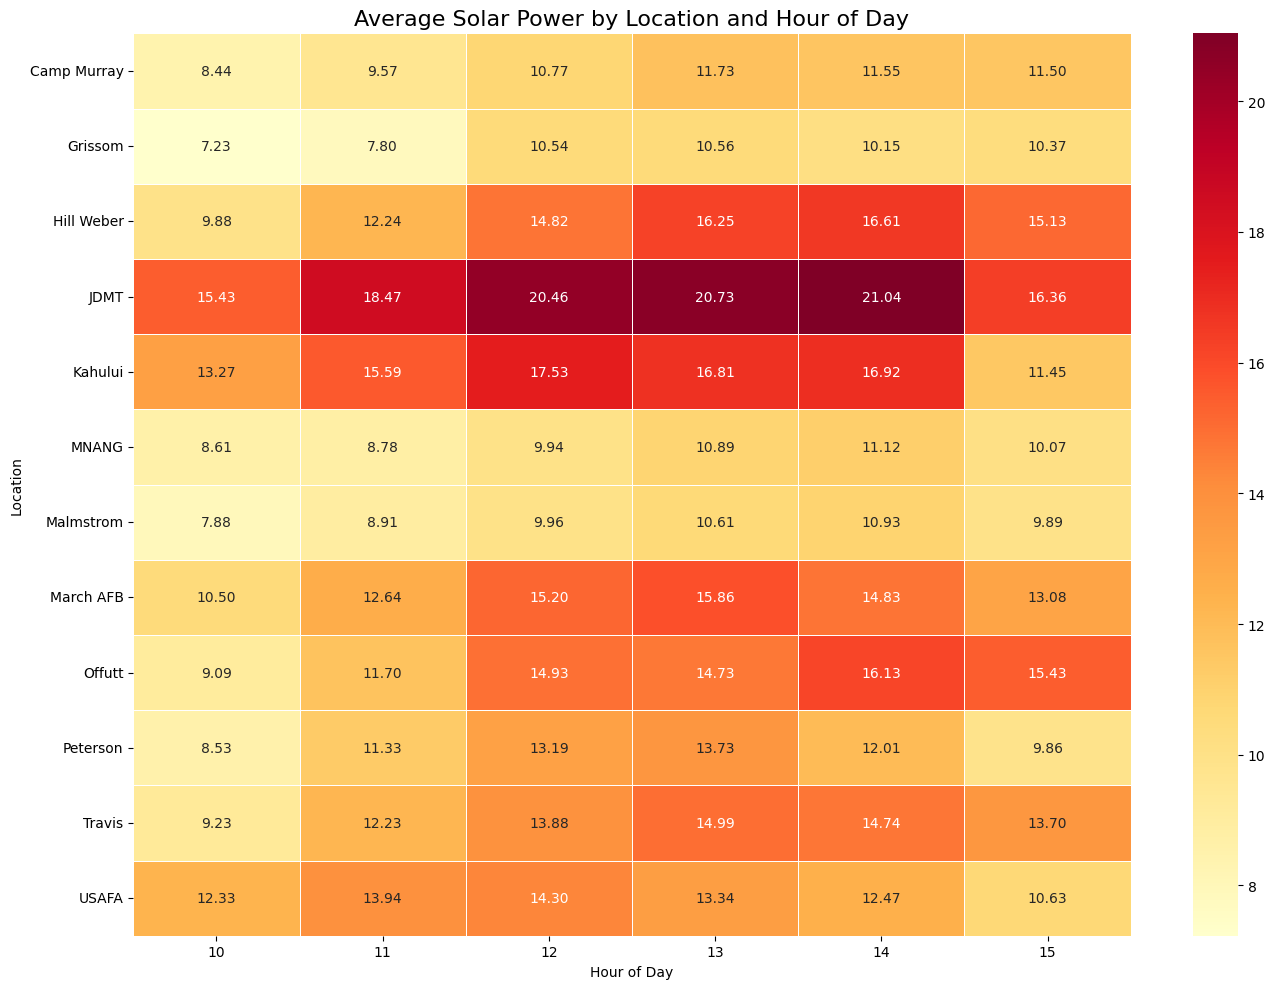

In [59]:
# Create a heatmap of average power by location and hour
location_hour_power = df.groupby(['Location', 'Hour'])['PolyPwr'].mean().reset_index()
print("Average Solar Power by Location and Hour:")
print(location_hour_power.sort_values('PolyPwr', ascending=False).head(15))

# Plot heatmap of average power by location and hour
plt.figure(figsize=(14, 10))
pivot_data = location_hour_power.pivot(index='Location', columns='Hour', values='PolyPwr')
sns.heatmap(pivot_data, cmap='YlOrRd', annot=True, fmt='.2f', linewidths=0.5)
plt.title('Average Solar Power by Location and Hour of Day', fontsize=16)
plt.xlabel('Hour of Day')
plt.ylabel('Location')
plt.tight_layout()
plt.show()

In [60]:
# # Alternative : Geographic visualization of solar power potential
# import matplotlib.pyplot as plt
# import seaborn as sns
# from mpl_toolkits.basemap import Basemap

# # Create a figure for the map
# plt.figure(figsize=(12, 8))

# # Create a basemap of the US
# m = Basemap(llcrnrlon=-130, llcrnrlat=25, urcrnrlon=-65, urcrnrlat=50,
#             projection='merc', resolution='i')
# m.drawcoastlines()
# m.drawcountries()
# m.drawstates()
# m.fillcontinents(color='lightgray', lake_color='lightblue')
# m.drawmapboundary(fill_color='lightblue')

# # Get coordinates and power data
# lats = df['Latitude'].values
# lons = df['Longitude'].values
# power = df['PolyPwr'].values

# # Convert coordinates to map projection
# x, y = m(lons, lats)

# # Create a scatter plot with power values
# scatter = m.scatter(x, y, c=power, cmap='YlOrRd', alpha=0.7, 
#                    s=200, edgecolor='k', linewidth=0.5)

# # Add a colorbar
# cbar = plt.colorbar(scatter, label='Solar Power Output (PolyPwr)')

# # Add title and labels
# plt.title('Geographic Distribution of Solar Power Potential', fontsize=16)

# plt.tight_layout()
# plt.show()

In [61]:
# Checking dataframe after initial transformation
df.head()

,Datetime,Date,Time,Year,Month,Day,Hour,Location,Latitude,Longitude,Altitude,Season,Humidity,AmbientTemp,Wind.Speed,Visibility,Pressure,Cloud.Ceiling,PolyPwr
0,2017-12-03 11:45:00,2017-12-03,11:45,2017,12,3,11,Camp Murray,47.11,-122.57,84,Winter,81.71997,12.86919,5,10.0,1010.6,722,2.42769
1,2017-12-03 13:15:00,2017-12-03,13:15,2017,12,3,13,Camp Murray,47.11,-122.57,84,Winter,96.64917,9.66415,0,10.0,1011.3,23,2.46273
2,2017-12-03 13:30:00,2017-12-03,13:30,2017,12,3,13,Camp Murray,47.11,-122.57,84,Winter,93.61572,15.44983,5,10.0,1011.6,32,4.46836
3,2017-12-04 12:30:00,2017-12-04,12:30,2017,12,4,12,Camp Murray,47.11,-122.57,84,Winter,77.21558,10.36659,5,2.0,1024.4,6,1.65364
4,2017-12-04 14:15:00,2017-12-04,14:15,2017,12,4,14,Camp Murray,47.11,-122.57,84,Winter,54.80347,16.85471,3,3.0,1023.7,9,6.57939


# Descriptive Statistics

In [20]:
# Grouping columns based on their types
nums = ['Altitude', 'Hour', 'Humidity', 'AmbientTemp', 'Wind.Speed', 'Visibility', 'Pressure', 'Cloud.Ceiling', 'PolyPwr']
cats = ['Location', 'Season']
dates = ['Datetime']

In [21]:
# Describe numerical columns
df[nums].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Altitude,21045.0,798.843668,770.681794,1.00000,2.00000,458.00000,1370.00000,1947.00000
Hour,21045.0,12.627845,1.672952,10.00000,11.00000,13.00000,14.00000,15.00000
Humidity,21045.0,37.121941,23.823011,0.00000,17.52930,33.12378,52.59399,99.98779
AmbientTemp,21045.0,29.285117,12.366820,-19.98177,21.91528,30.28915,37.47467,65.73837
Wind.Speed,21045.0,10.318318,6.385030,0.00000,6.00000,9.00000,14.00000,49.00000
Visibility,21045.0,9.700071,1.351949,0.00000,10.00000,10.00000,10.00000,10.00000
Pressure,21045.0,925.944747,85.215659,781.70000,845.50000,961.10000,1008.90000,1029.50000
Cloud.Ceiling,21045.0,515.966785,301.903379,0.00000,140.00000,722.00000,722.00000,722.00000
PolyPwr,21045.0,12.978583,7.123255,0.25733,6.40457,13.79870,18.86365,34.28502


In [23]:
# Describe categorical columns
df[cats].describe().transpose()

,count,unique,top,freq
Location,21045,12,Travis,2746
Season,21045,4,Summer,8208


In [24]:
# Categorical Feature Counts
for col in cats :
  print(f'Value counts untuk {col} :')
  print(df[col].value_counts(), '\n')

Value counts untuk Location :
Location
Travis         2746
Peterson       2640
USAFA          2573
Hill Weber     2384
March AFB      2204
JDMT           1779
Malmstrom      1517
Grissom        1487
Camp Murray    1113
Kahului         941
Offutt          881
MNANG           780
Name: count, dtype: int64 

Value counts untuk Season :
Season
Summer    8208
Spring    4808
Fall      4407
Winter    3622
Name: count, dtype: int64 



In [62]:
# Describe date columns
df['Datetime'].describe().transpose()

count                            21045
mean     2018-02-26 16:05:39.600855552
min                2017-05-23 11:00:00
25%                2017-11-10 13:00:00
50%                2018-03-17 10:15:00
75%                2018-06-23 10:00:00
max                2018-10-04 15:00:00
Name: Datetime, dtype: object

# Univariate Analysis

## Numerical Columns

In [25]:
# Check number of subplots that will be make
len(df[nums].columns)

9

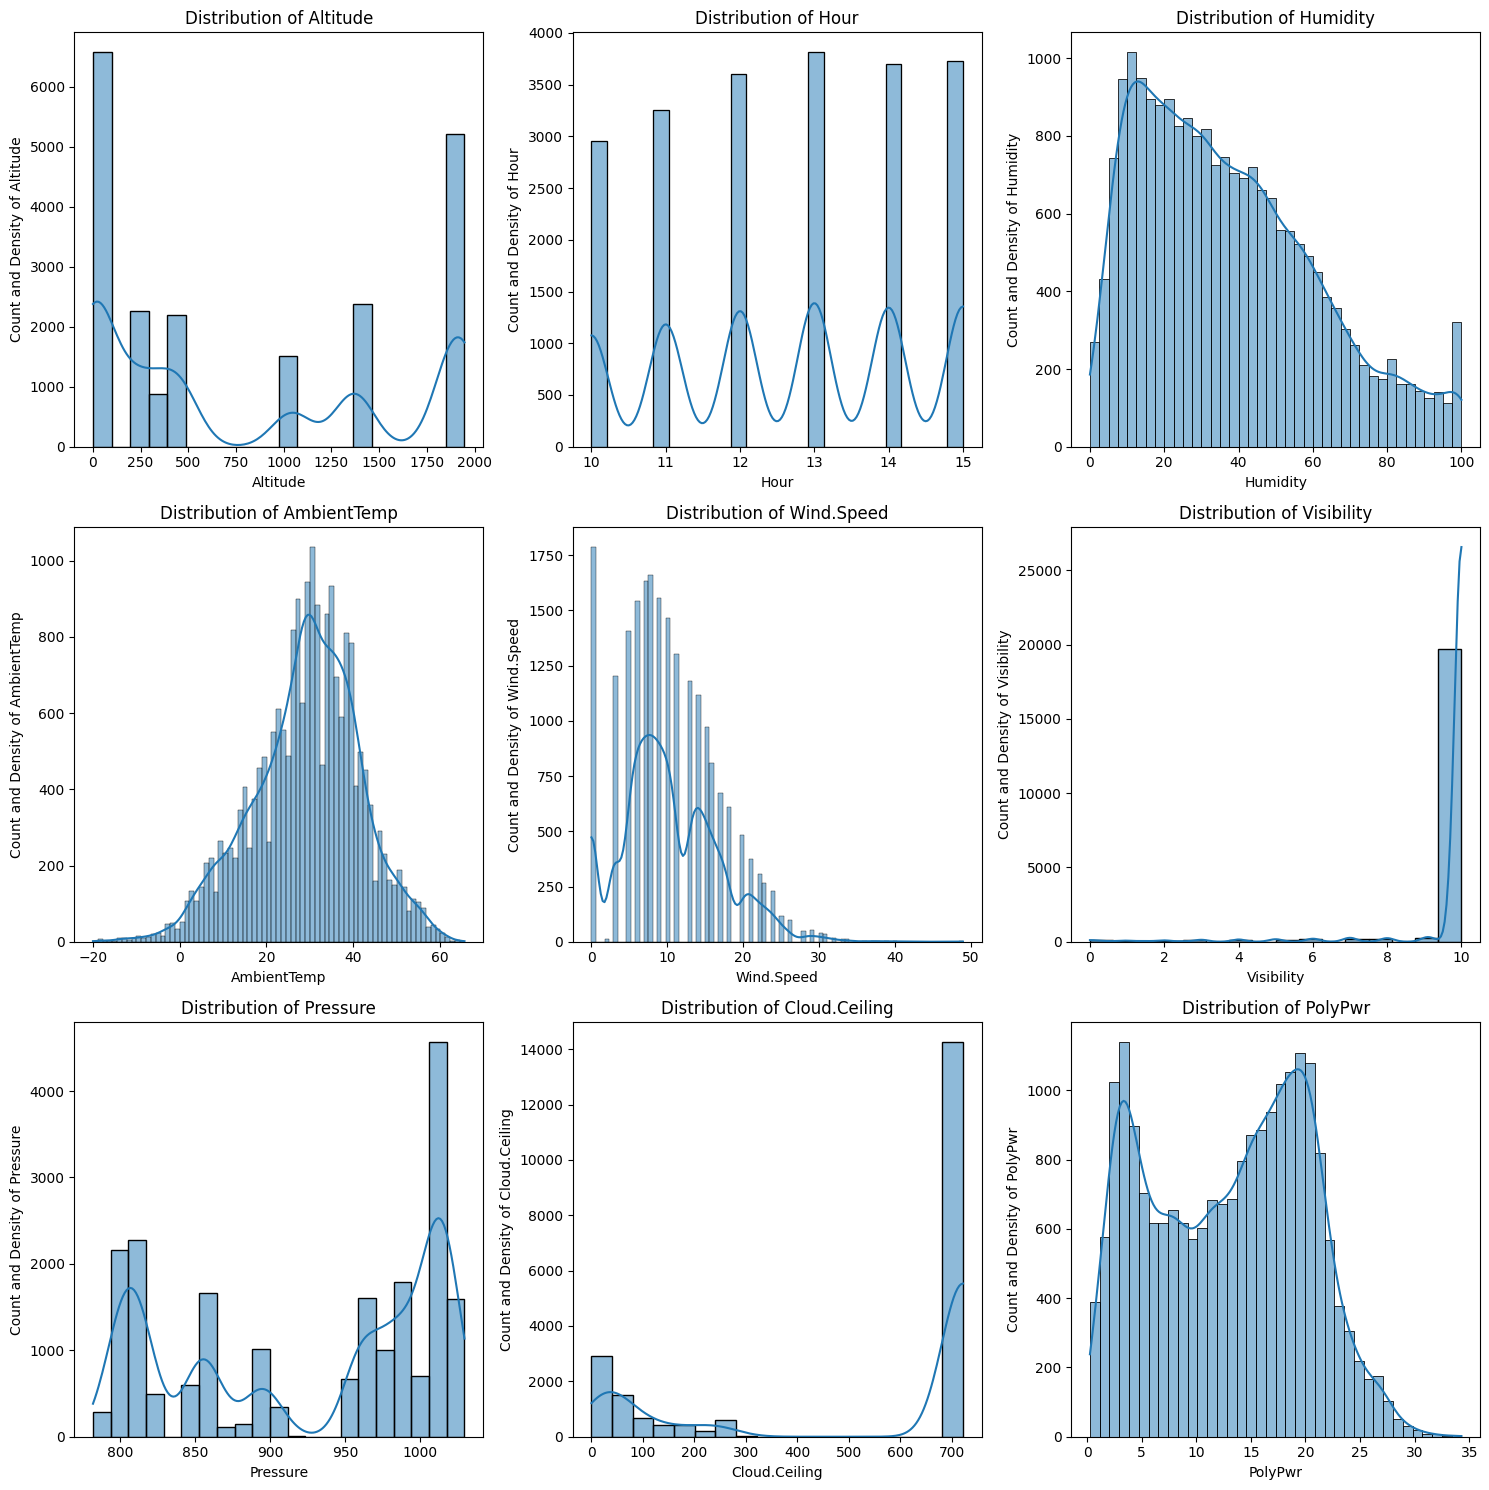

In [34]:
# Histplot with kde

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15,15))
axes = axes.flatten()

for i in range(len(nums)) :
    sns.histplot(data=df, ax=axes[i], x=nums[i], kde=True)
    axes[i].set_title(f'Distribution of {nums[i]}')
    axes[i].set_ylabel(f'Count and Density of {nums[i]}')
    axes[i].set_xlabel(f'{nums[i]}')

# Remove the last subplot if there are fewer features than subplots
if len(nums) < len(axes) :
    axes[len(nums)].remove()

plt.tight_layout()

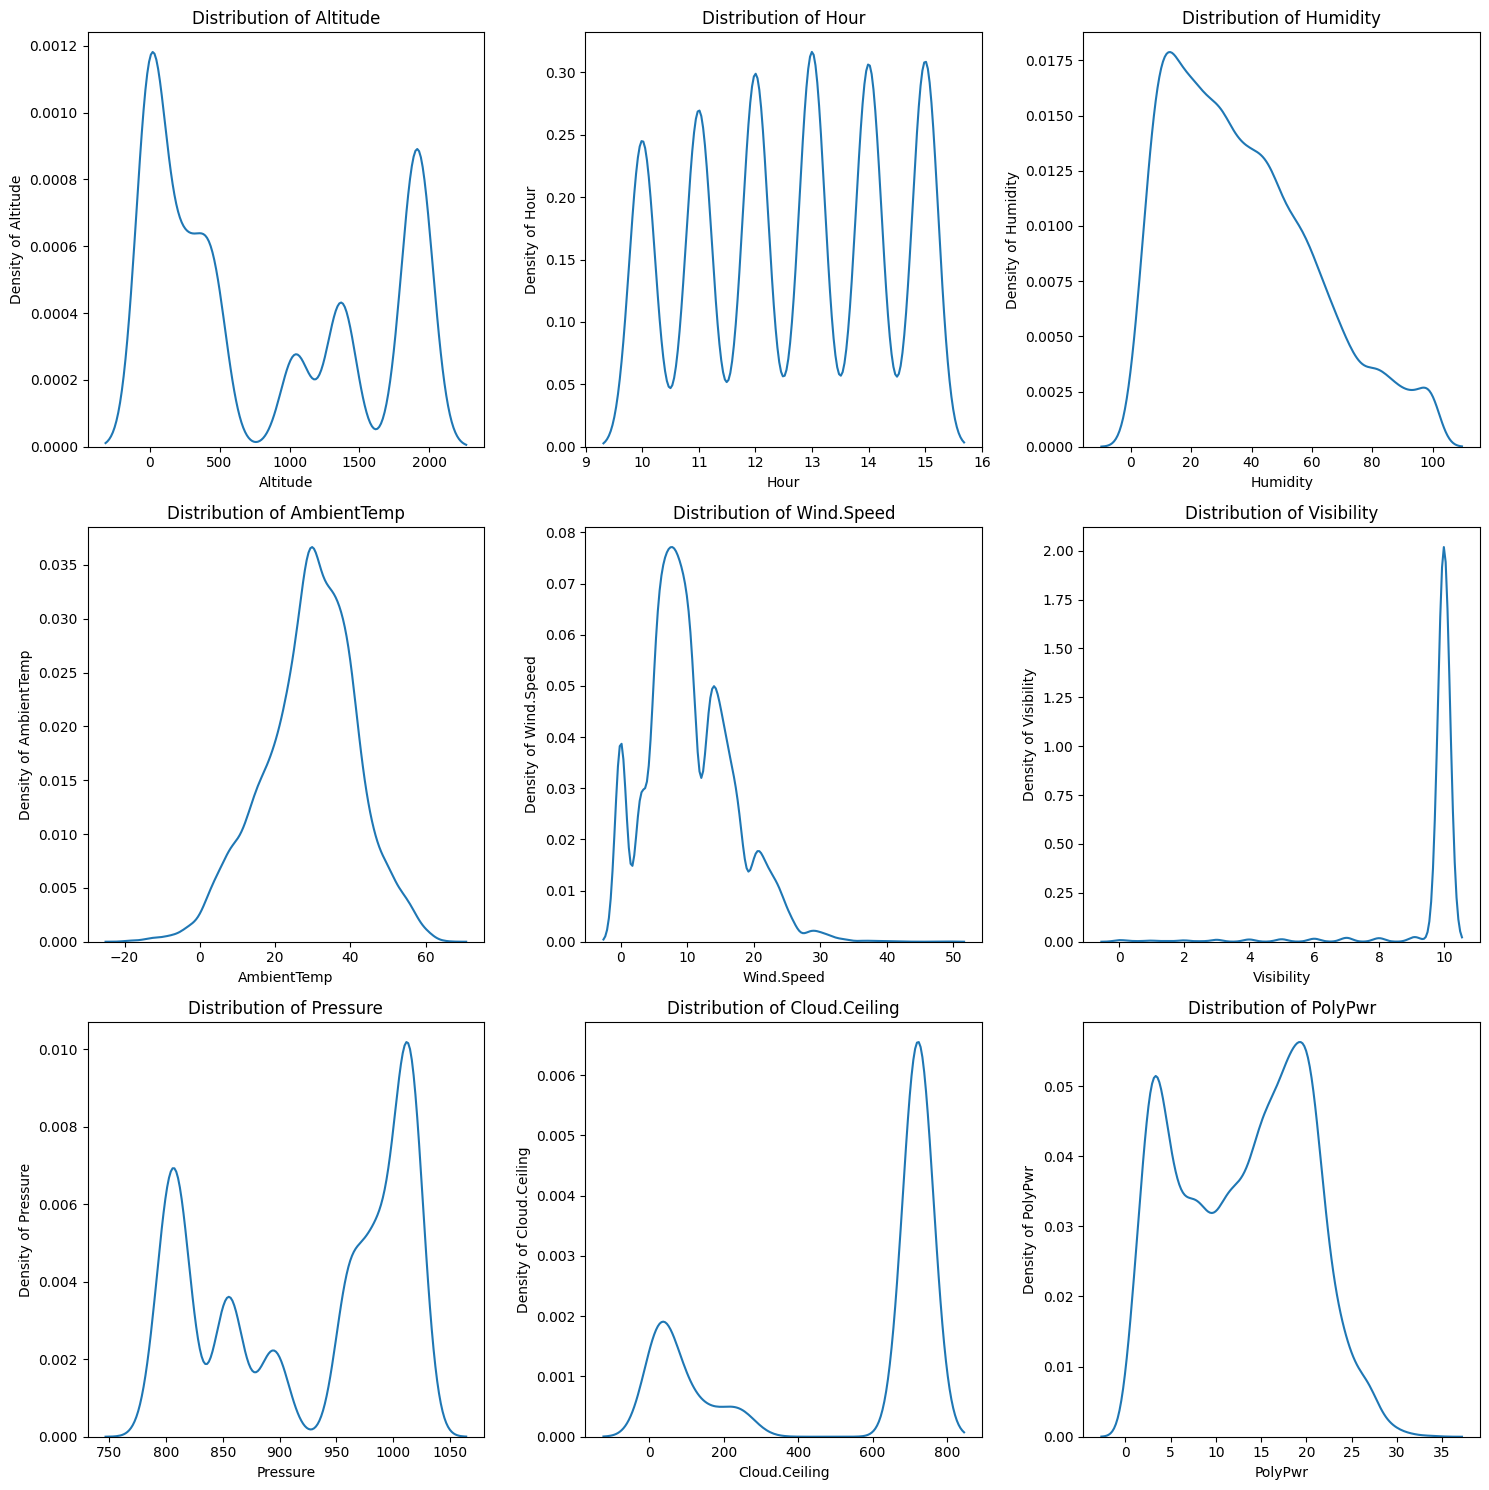

In [36]:
# Focusing only on kde

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15,15))
axes = axes.flatten()

for i in range(len(nums)) :
    sns.kdeplot(data=df, ax=axes[i], x=nums[i])
    axes[i].set_title(f'Distribution of {nums[i]}')
    axes[i].set_ylabel(f'Density of {nums[i]}')
    axes[i].set_xlabel(f'{nums[i]}')

# Remove the last subplot if there are fewer features than subplots
if len(nums) < len(axes) :
    axes[len(nums)].remove()

plt.tight_layout()

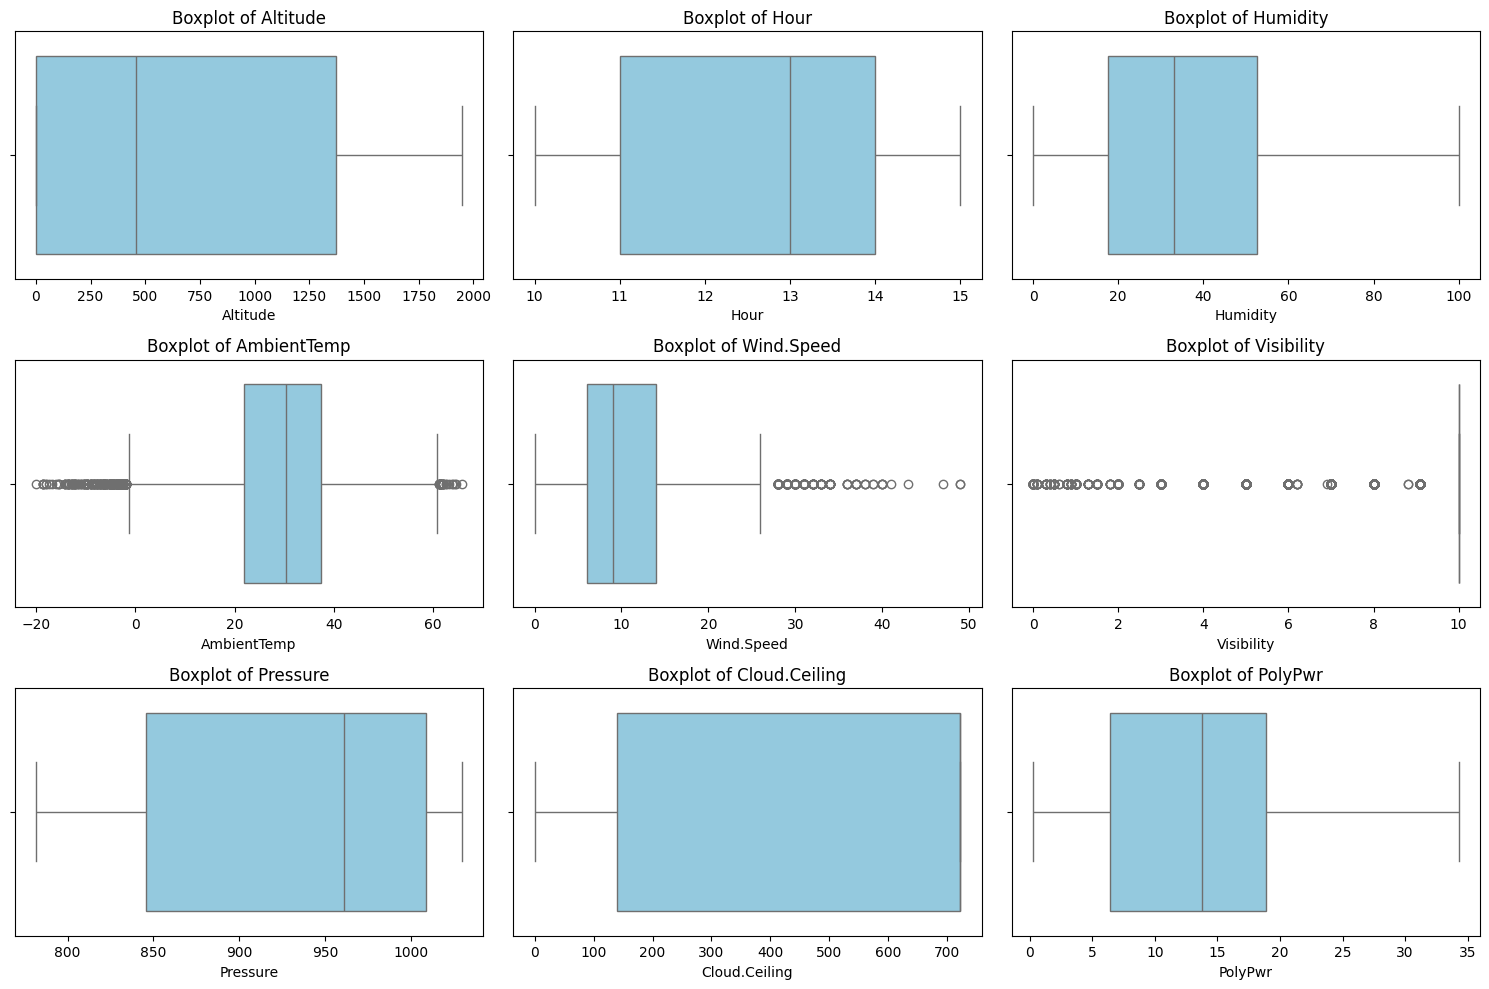

In [37]:
# Boxplot
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i in range(len(nums)) :
  sns.boxplot(data=df, ax=axes[i], x=nums[i], orient='h', color='skyblue')
  axes[i].set_title(f'Boxplot of {nums[i]}')

# Remove the last subplot if there are fewer features than subplots
if len(nums) < len(axes):
    axes[len(nums)].remove()

plt.tight_layout()

There are not many features with outliers, only AmbientTemp, Wind.Speed, and Visibility

## Categorical Columns

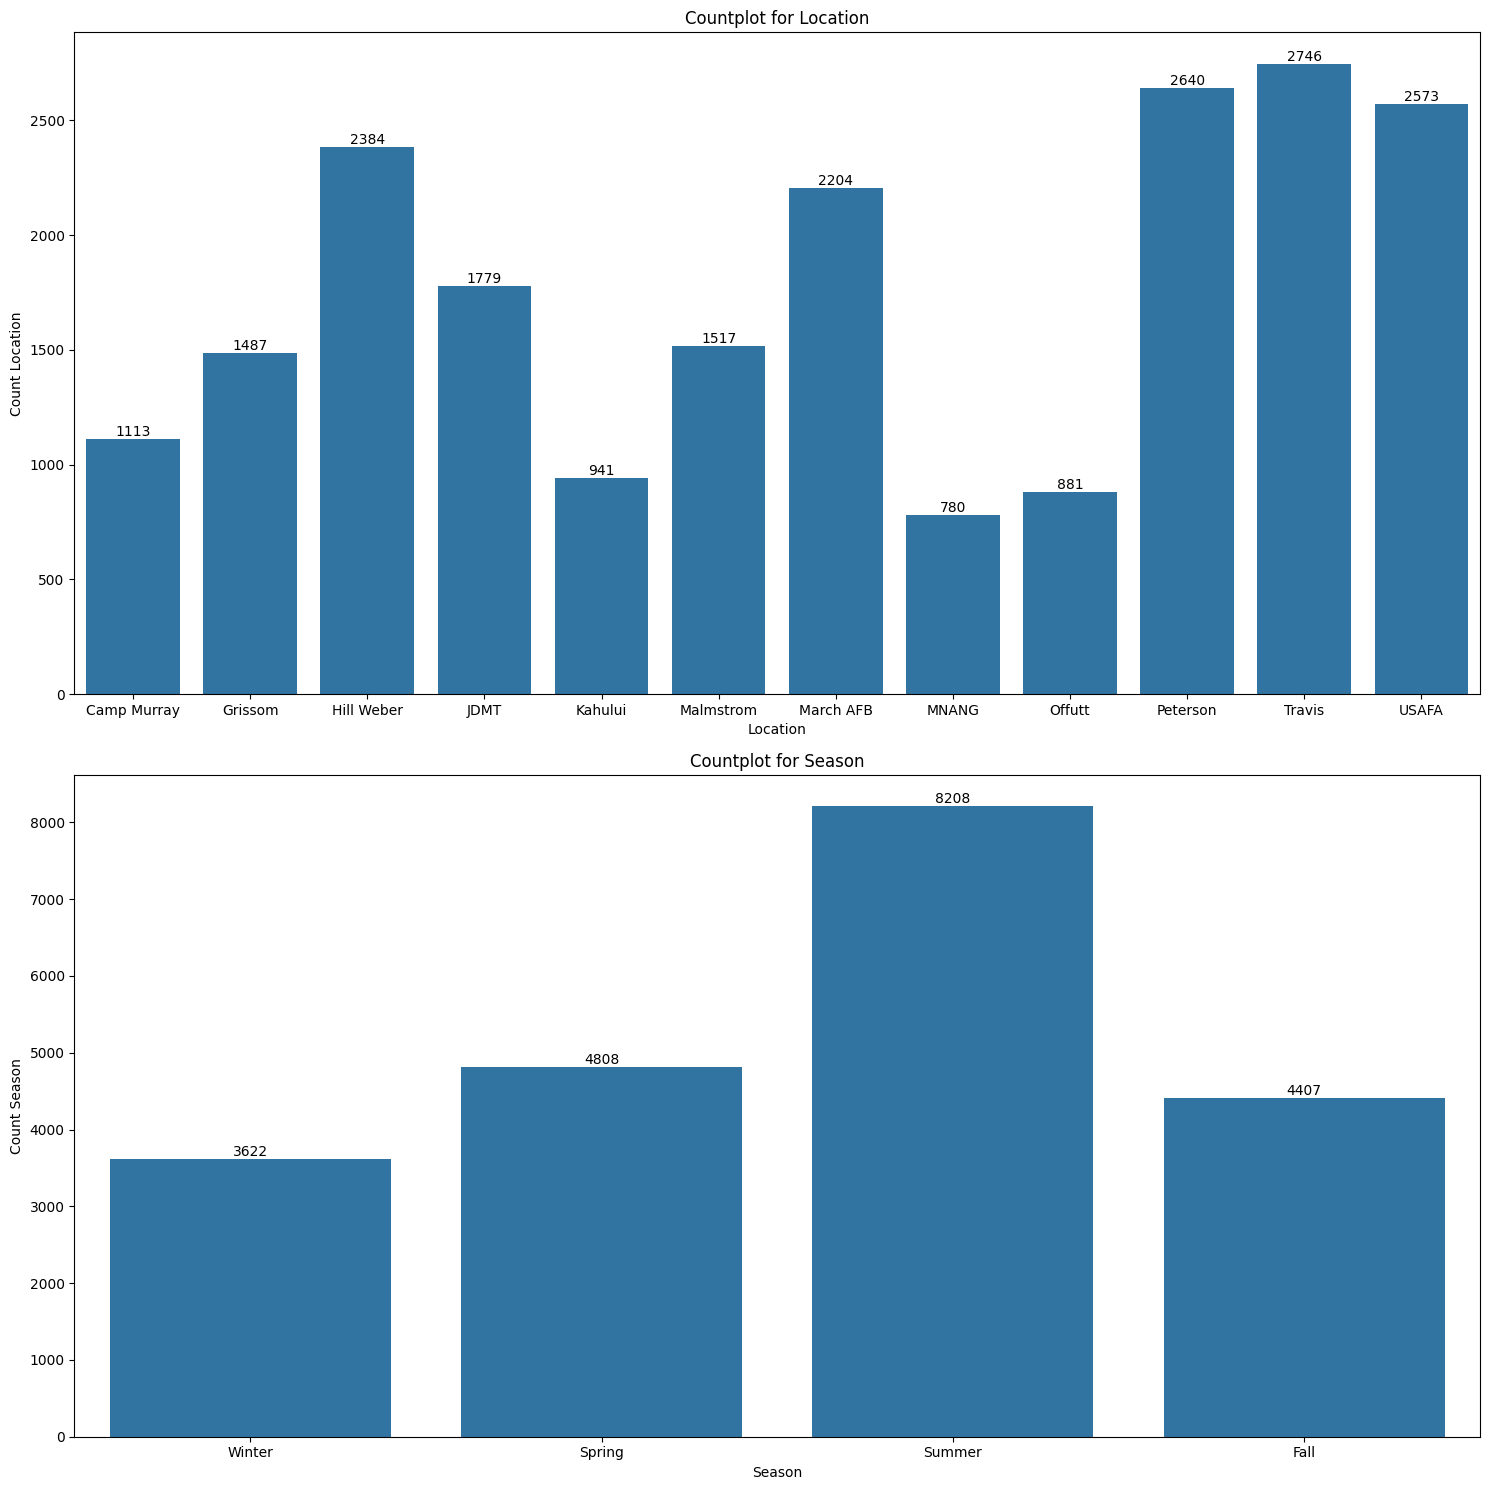

In [38]:
#Countplot
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 15))

for i in range(len(cats)):
    ax = sns.countplot(data=df, ax=axes[i], x=cats[i])
    axes[i].set_title(f'Countplot for {cats[i]}')
    axes[i].set_ylabel(f'Count {cats[i]}')
    axes[i].tick_params(axis='x')
    axes[i].bar_label(axes[i].containers[0])

plt.tight_layout()
plt.show()

# Bivariate/Multivariate Analysis

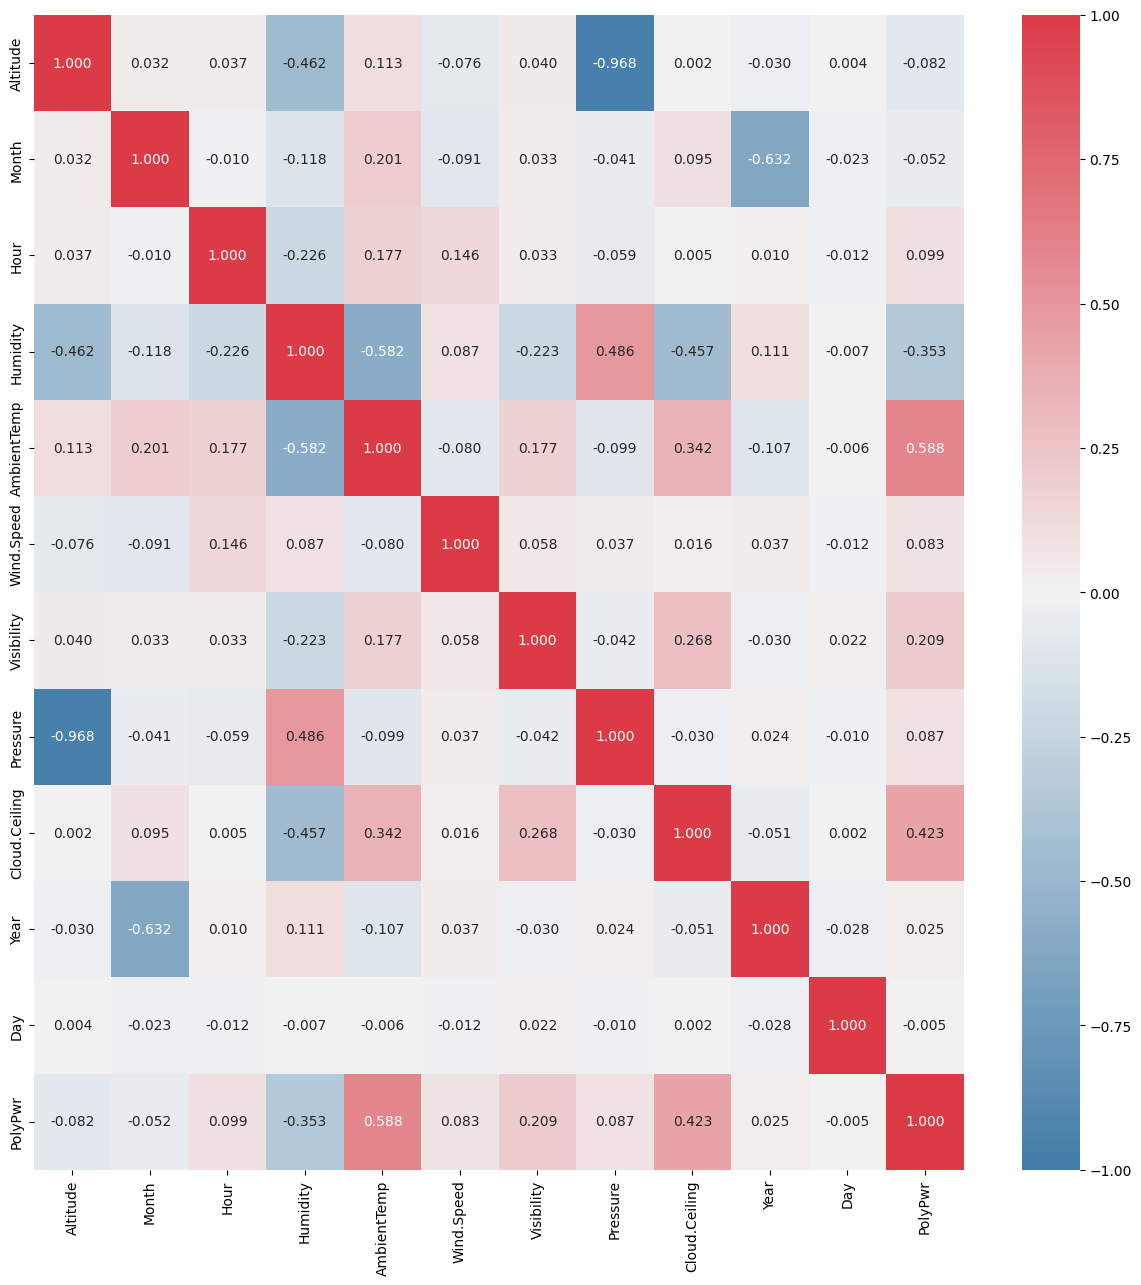

In [25]:
# Heatmap (corr spearman)
plt.figure(figsize=(15,15))
cmap_custom = sns.diverging_palette(240, 10, as_cmap=True)
sns.heatmap(data = df.corr(numeric_only=True, method='spearman'), cmap=cmap_custom, annot=True, fmt='.3f', vmin=-1, vmax=1)
plt.show()

In this case we use spearman correlation that is more robust/accurate in capturing non-linear (can be seen from pairplot down below) correlation of features. Some feature that have high correlation to target are Humidity, AmbientTemp, Visibility, and Cloud.Ceiling. We also likely to drop or not use Altitude feature since it has really high correlation to Pressure to avoid multicollinearity.

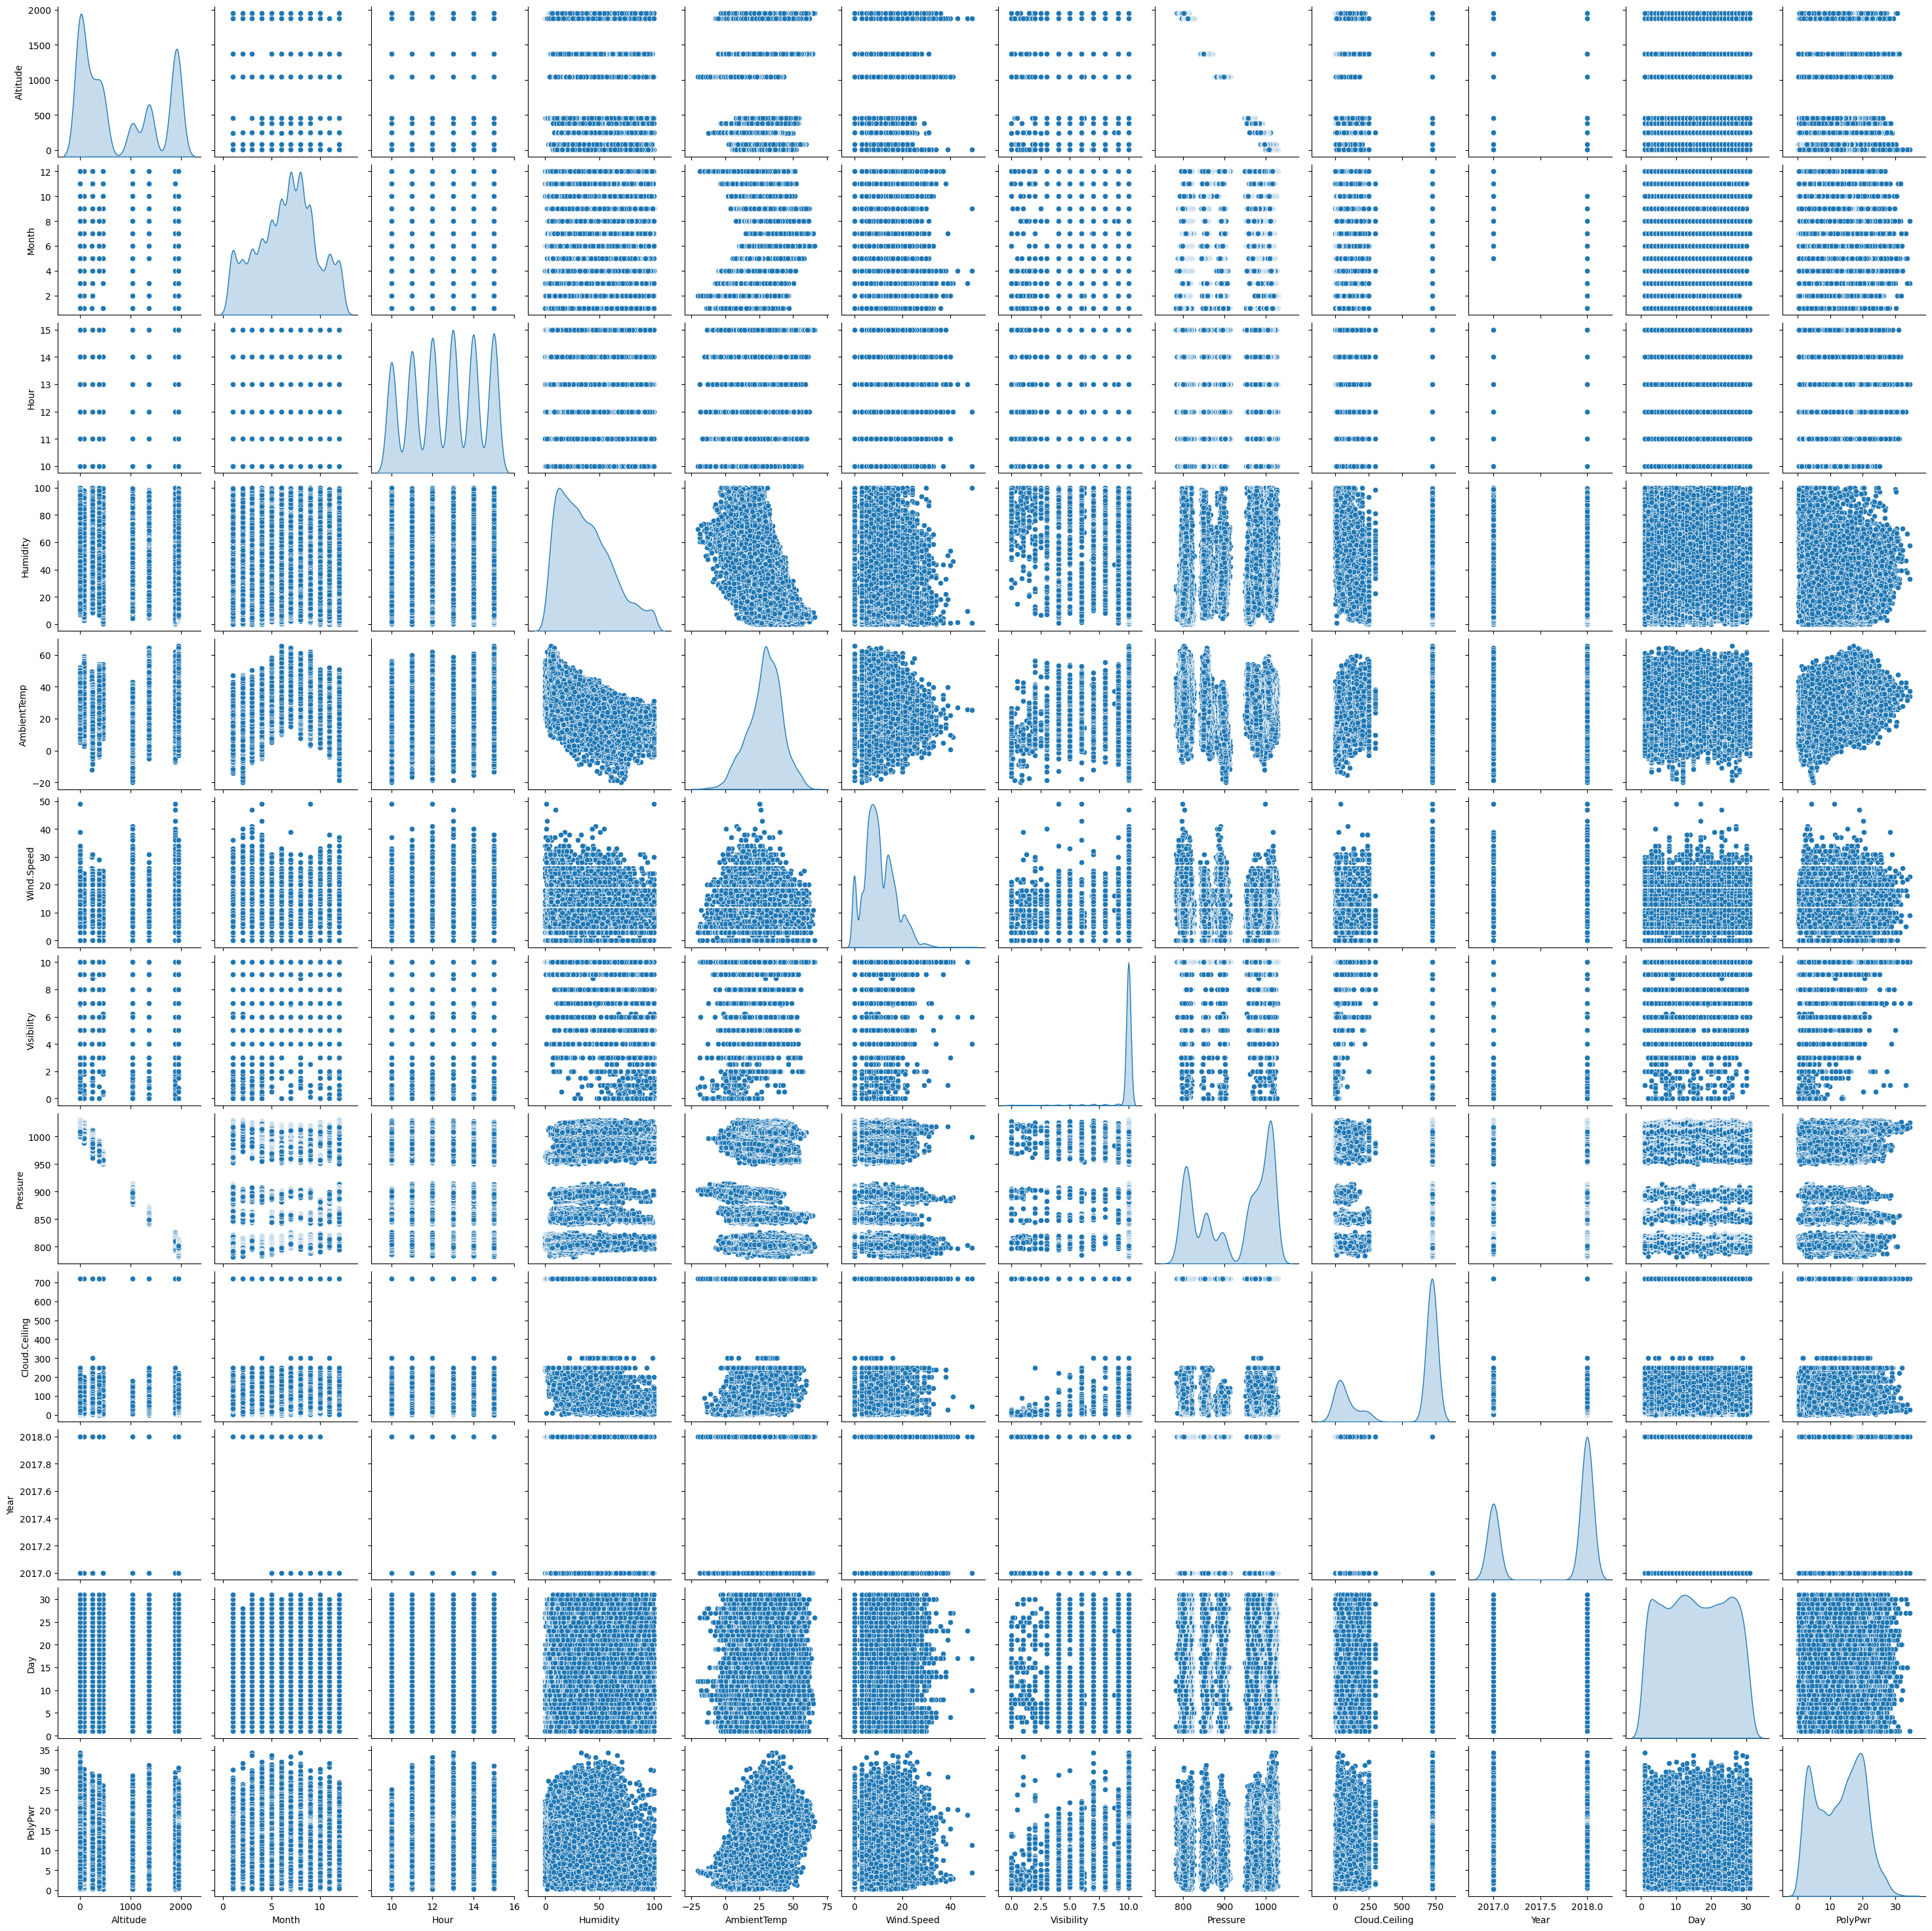

In [26]:
# Pairplot
sns.pairplot(df, diag_kind='kde')
plt.show()

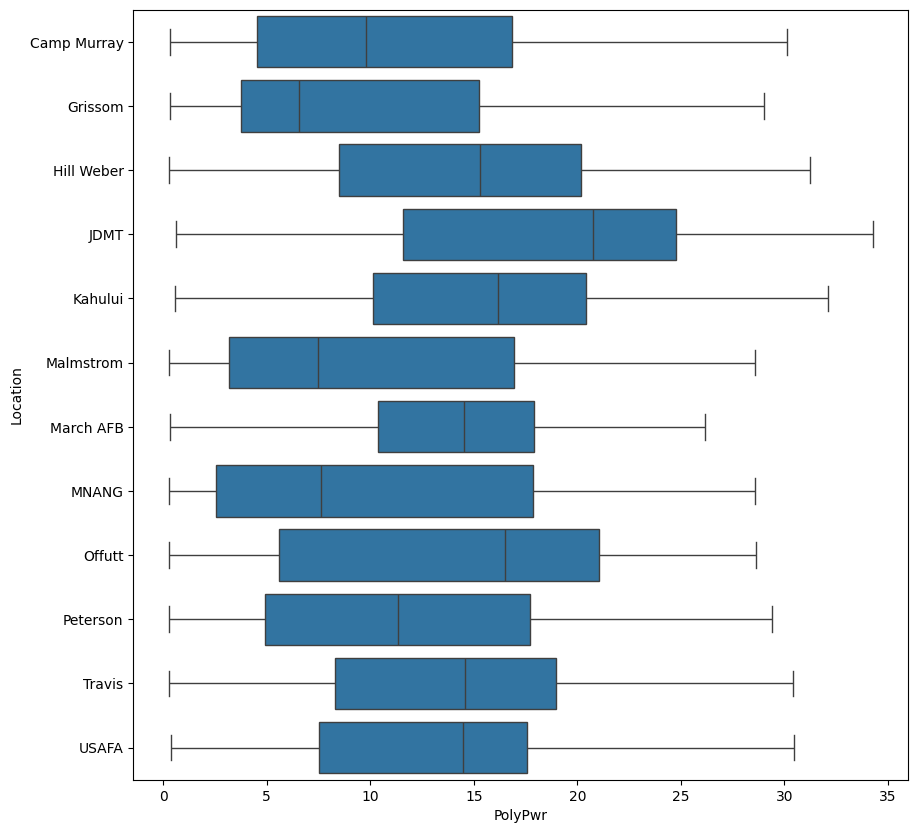

In [27]:
#Boxplot of PolyPwr by Location
plt.figure(figsize=(10,10))
sns.boxplot(data=df, x='PolyPwr', y='Location')
plt.show()

In [28]:
#Mean PolyPwr by Season
df_mean_power_season = df.groupby('Season').agg({'PolyPwr' : ['mean']})
df_mean_power_season

,PolyPwr
,mean
Season,
Fall,11.167499
Spring,14.192405
Summer,15.320546
Winter,8.263660


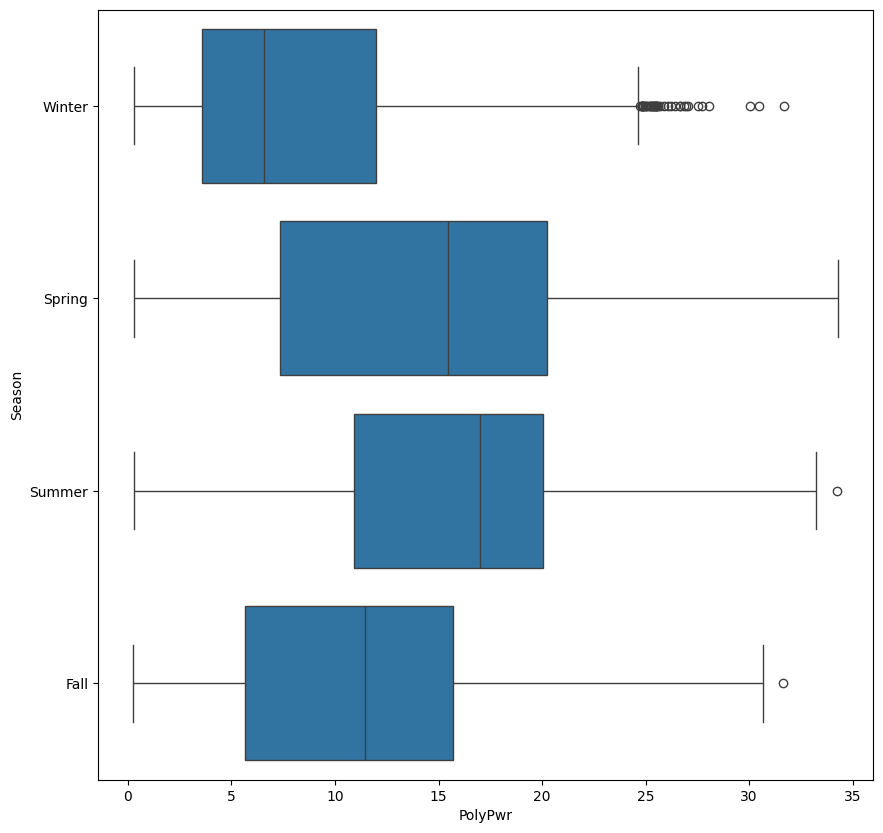

In [29]:
#Boxplot of PolyPwr by Season
plt.figure(figsize=(10,10))
sns.boxplot(data=df, x='PolyPwr', y='Season')
plt.show()

Summer as expected have the highest median PolyPwr with the lowest variability and highest overall mean of PolyPwr from all season

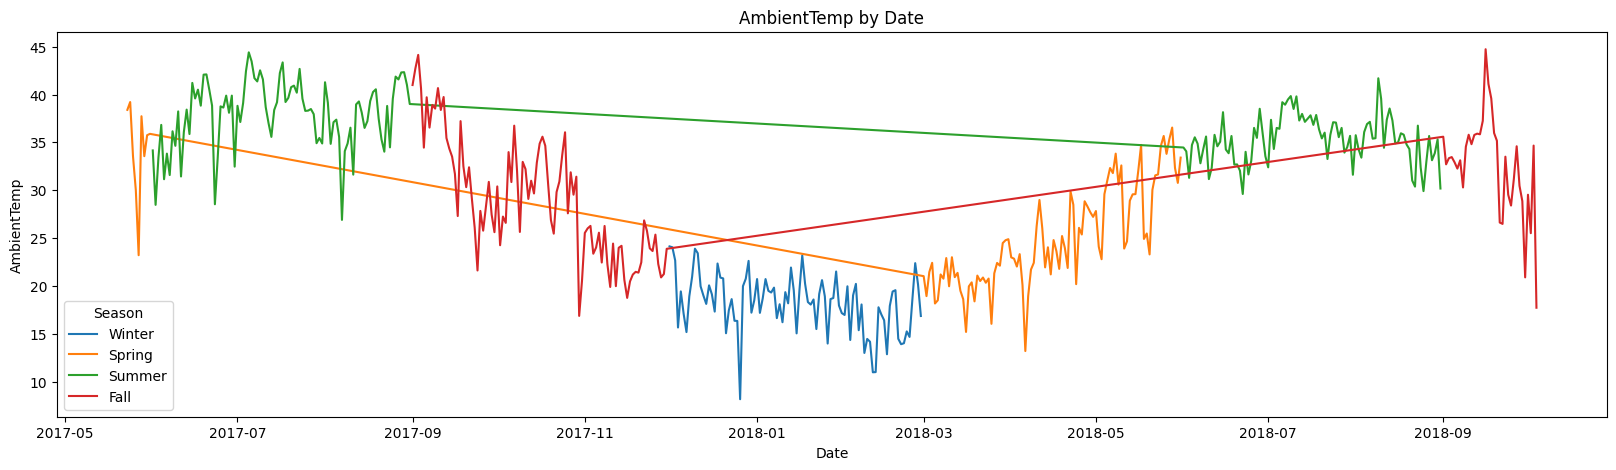

In [41]:
#AmbientTemp by Date per Season
plt.figure(figsize=(20,5))
sns.lineplot(data=df, x='Date', y='AmbientTemp', hue='Season', ci=None)
plt.ylabel('AmbientTemp')
plt.xlabel('Date')
plt.title('AmbientTemp by Date')
plt.show()

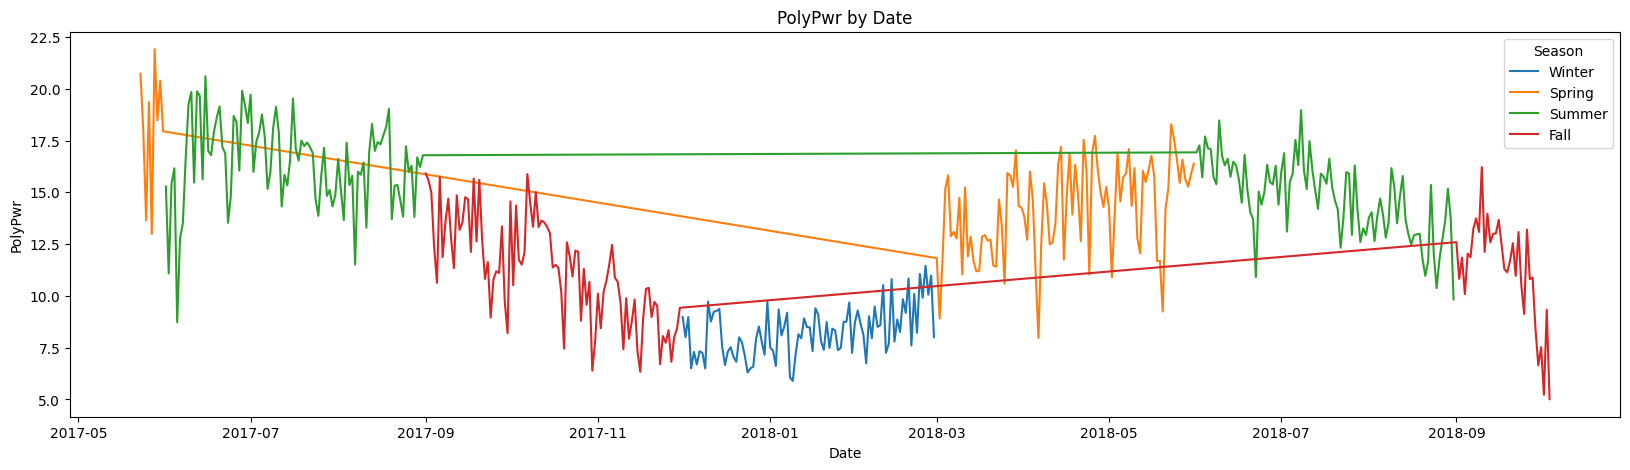

In [42]:
#Polypwr by Date per Season
plt.figure(figsize=(20,5))
sns.lineplot(data=df, x='Date', y='PolyPwr', hue='Season', ci=None)
plt.ylabel('PolyPwr')
plt.xlabel('Date')
plt.title('PolyPwr by Date')
plt.show()

The ambient temperature does have the same trend with PolyPwr generated where it went down during Winter

At first, I wanted to create a PolyPwr plot by hour because from my experience learning about solar cell irradiation, there is something called peak hours. These are periods during the day when solar radiation reaches its highest intensity, and solar cells receive sunlight with maximum intensity, resulting in optimal electricity production. However, I just realized that the 'Hour' feature in this dataset only represents the peak hours, not all hours in a day. Additionally, the distribution, as seen in the pair plot, does not allow for depicting a curve that typically has a peak shape during peak hours.

# Pre-Processing & Feature Engineering

In [43]:
# Make a copy of original dataframe for preprocessing and encoding process
df_encoding = df.copy()
df_encoding.sample(5)

,Location,Date,Altitude,Month,Hour,Season,Humidity,AmbientTemp,Wind.Speed,Visibility,Pressure,Cloud.Ceiling,Year,Day,PolyPwr
14483,Peterson,2018-02-21,1879,2,10,Winter,13.43994,16.77666,5,10.0,814.8,722,2018,21,3.87133
12870,Offutt,2018-08-04,380,8,10,Summer,99.98779,22.54471,9,6.0,975.1,50,2018,4,1.27676
20040,USAFA,2018-05-08,1947,5,12,Spring,15.64331,33.62259,8,10.0,800.6,722,2018,8,19.34276
6369,JDMT,2018-03-01,2,3,13,Spring,27.30103,44.45625,13,10.0,1016.9,722,2018,1,8.88449
7330,Kahului,2018-04-05,2,4,10,Spring,61.95679,32.88490,24,10.0,1013.1,722,2018,5,6.31887


In [44]:
# Drop features that are irrelevant and we will not use for this modelling case
df_encoding = df_encoding.drop(columns=['Date', 'Altitude', 'Year'])

In [45]:
# One-hot encoding for Location
onehots = pd.get_dummies(df_encoding['Location'], prefix='Location')
onehots = onehots.astype(int)
df_encoding = df_encoding.join(onehots)

#Drop the Location after one-hot encoding
df_encoding.drop(columns='Location', inplace=True)

In [46]:
# One-hot encoding for Season
onehots = pd.get_dummies(df_encoding['Season'], prefix='Season')
onehots = onehots.astype(int)
df_encoding = df_encoding.join(onehots)

#Drop the Location after one-hot encoding
df_encoding.drop(columns='Season', inplace=True)

In [47]:
#Check dataframe after encoding and drop irrelevant features
df_encoding

,Month,Hour,Humidity,AmbientTemp,Wind.Speed,Visibility,Pressure,Cloud.Ceiling,Day,PolyPwr,Location_Camp Murray,Location_Grissom,Location_Hill Weber,Location_JDMT,Location_Kahului,Location_MNANG,Location_Malmstrom,Location_March AFB,Location_Offutt,Location_Peterson,Location_Travis,Location_USAFA,Season_Fall,Season_Spring,Season_Summer,Season_Winter
0,12,11,81.71997,12.86919,5,10.0,1010.6,722,3,2.42769,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,12,13,96.64917,9.66415,0,10.0,1011.3,23,3,2.46273,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2,12,13,93.61572,15.44983,5,10.0,1011.6,32,3,4.46836,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,12,12,77.21558,10.36659,5,2.0,1024.4,6,4,1.65364,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,12,14,54.80347,16.85471,3,3.0,1023.7,9,4,6.57939,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21040,9,15,11.66992,43.22510,14,10.0,802.3,722,28,9.79611,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0
21041,9,13,18.22510,28.98247,13,10.0,799.2,722,29,10.88992,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0
21042,9,14,15.52124,33.49167,10,10.0,798.4,722,29,8.24479,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0
21043,9,15,6.63452,51.62163,10,10.0,797.8,722,29,12.47328,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0


In [48]:
# Re-arrange the columns (PolyPwr in last)
df_1 = df_encoding.drop(columns='PolyPwr')
df_2 = df_encoding['PolyPwr']
df_encoding = pd.concat([df_1, df_2], axis='columns')

# Feature Selection

At first we will just use all the features that we got after pre-processing, this part is just additional check to compare the result of df.corr() with SelectKbest to see what will best features for prediction later

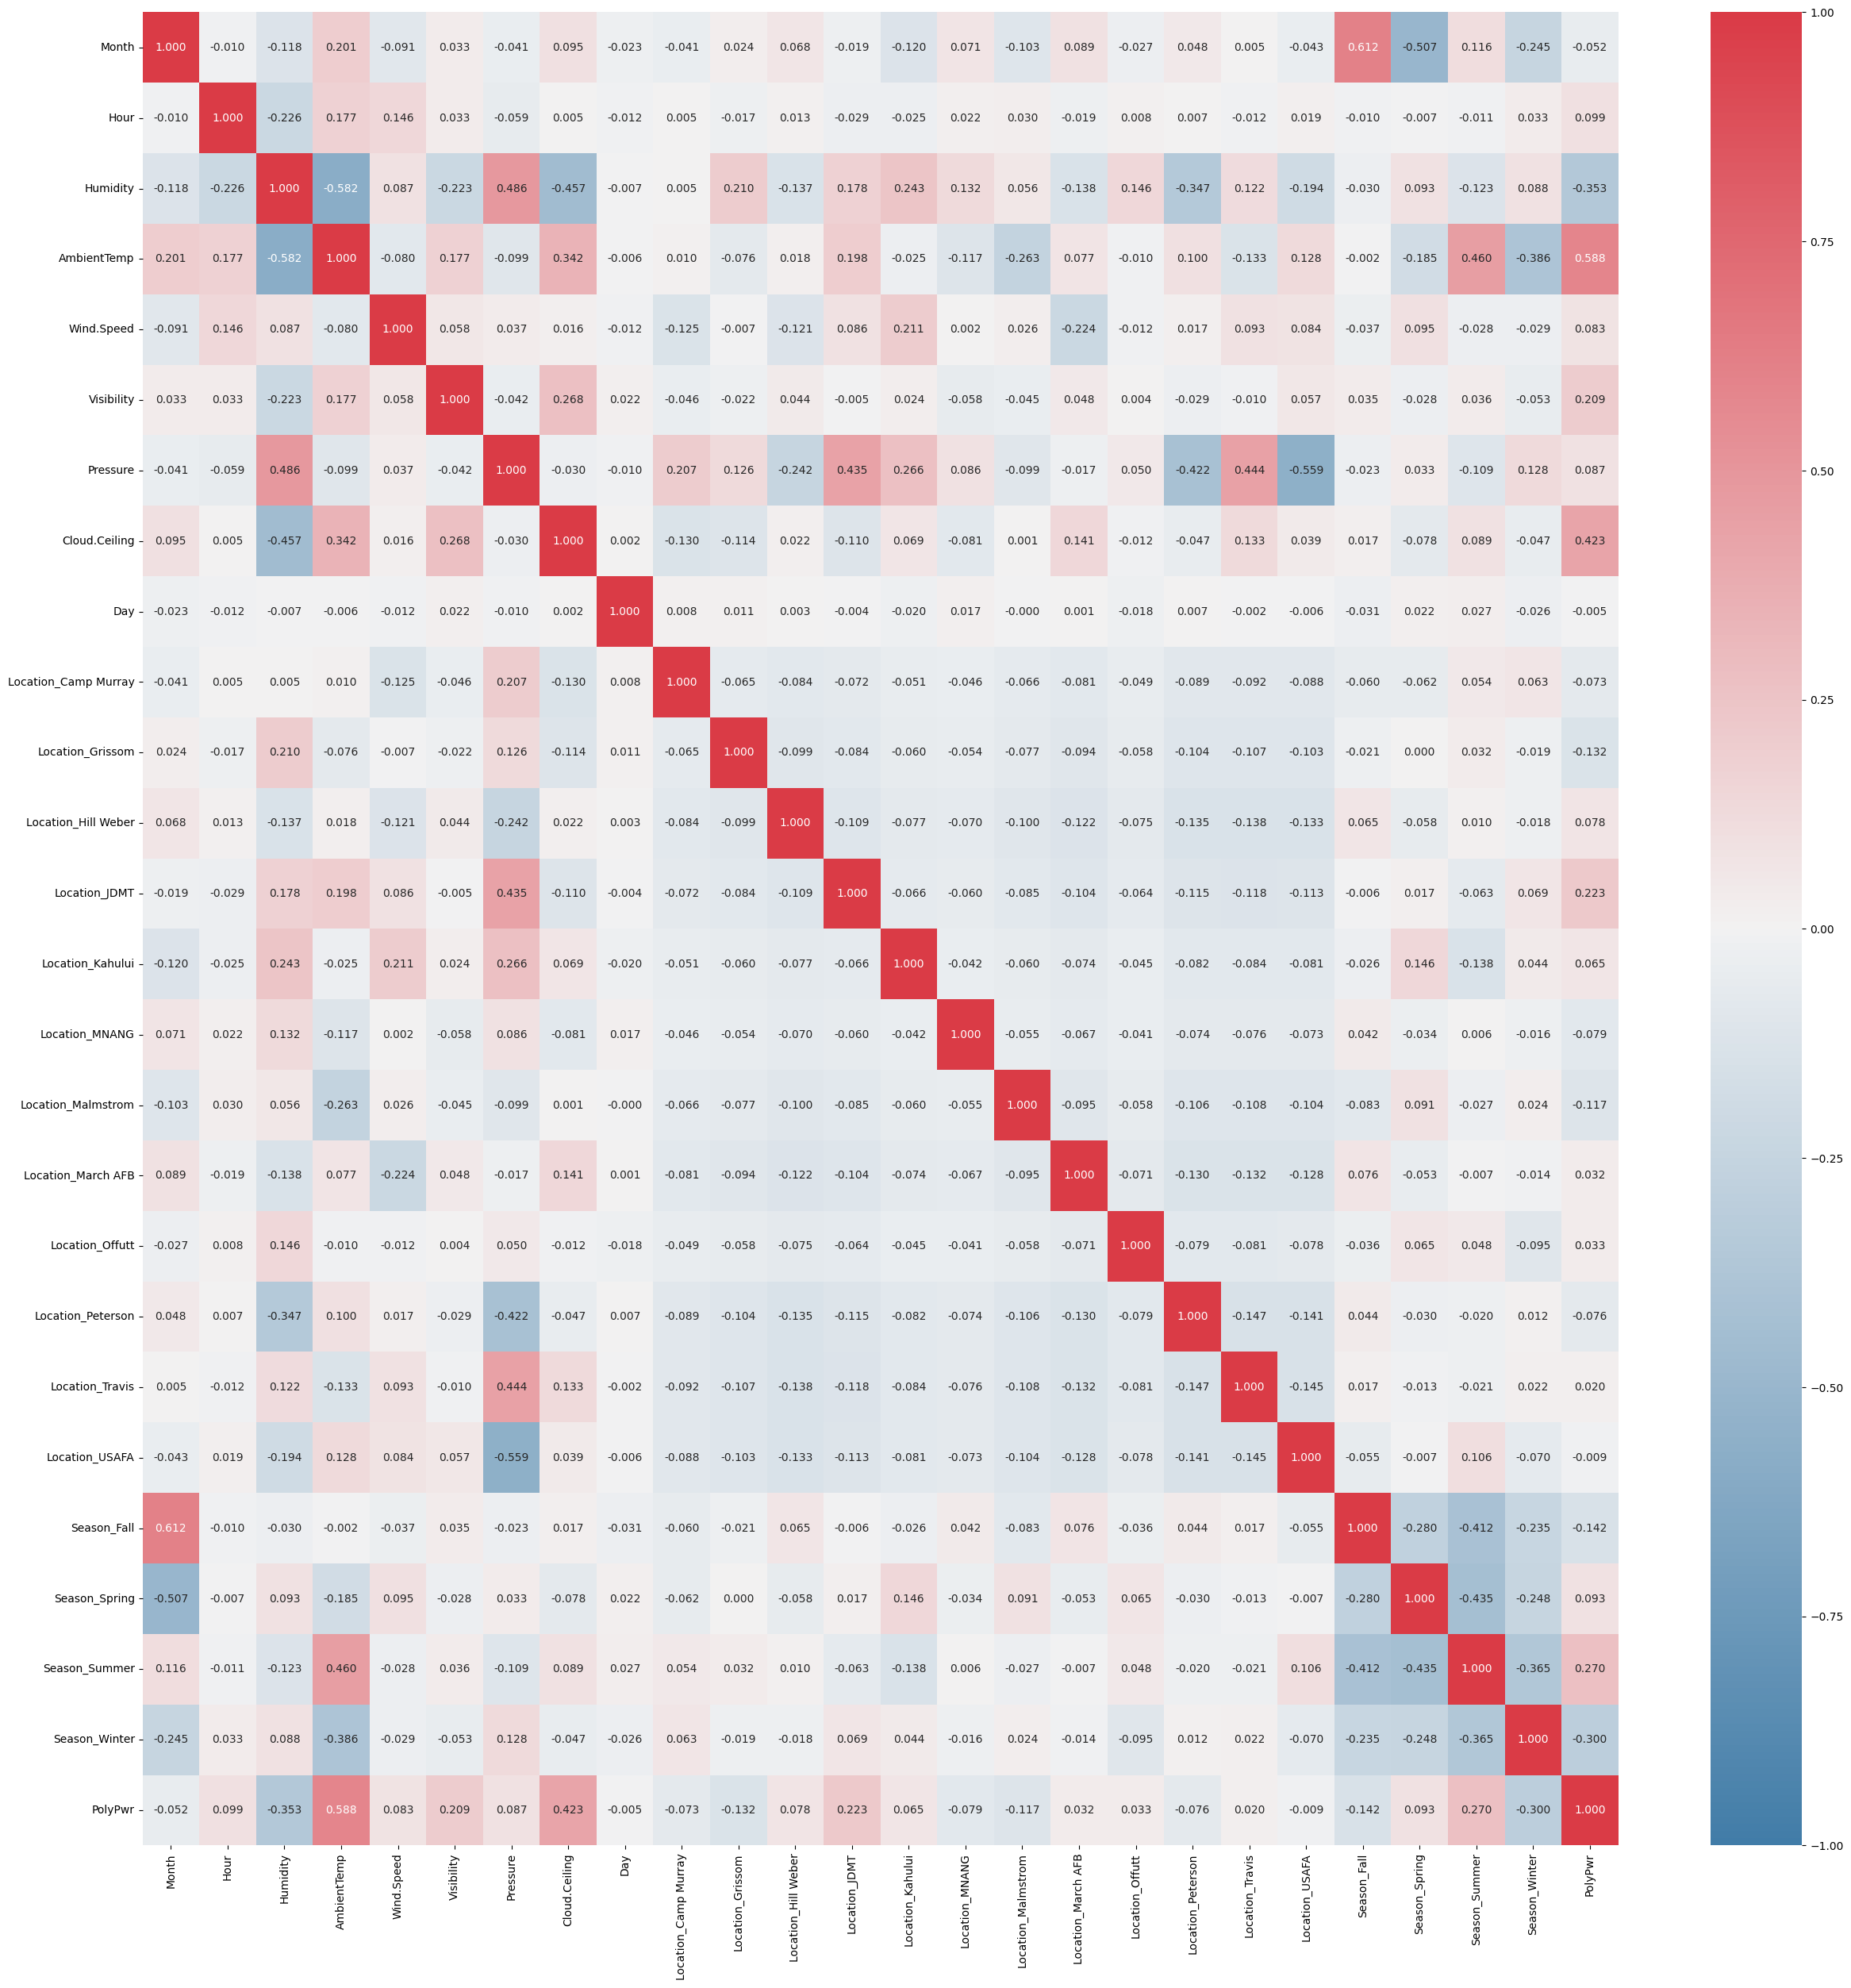

In [38]:
# Heatmap (corr spearman)
plt.figure(figsize=(30,30))
cmap_custom = sns.diverging_palette(240, 10, as_cmap=True)
sns.heatmap(data = df_encoding.corr(numeric_only=True, method='spearman'), cmap=cmap_custom, annot=True, fmt='.3f', vmin=-1, vmax=1)
plt.show()

In [49]:
# Create temporary dataframe for testing SelectKBest
df_feature_target_relation = df_encoding.copy()
df_feature_target_relation.head()

,Month,Hour,Humidity,AmbientTemp,Wind.Speed,Visibility,Pressure,Cloud.Ceiling,Day,Location_Camp Murray,Location_Grissom,Location_Hill Weber,Location_JDMT,Location_Kahului,Location_MNANG,Location_Malmstrom,Location_March AFB,Location_Offutt,Location_Peterson,Location_Travis,Location_USAFA,Season_Fall,Season_Spring,Season_Summer,Season_Winter,PolyPwr
0,12,11,81.71997,12.86919,5,10.0,1010.6,722,3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2.42769
1,12,13,96.64917,9.66415,0,10.0,1011.3,23,3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2.46273
2,12,13,93.61572,15.44983,5,10.0,1011.6,32,3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,4.46836
3,12,12,77.21558,10.36659,5,2.0,1024.4,6,4,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1.65364
4,12,14,54.80347,16.85471,3,3.0,1023.7,9,4,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,6.57939


In [51]:
#Calculation of feature importance score to target (numerical/categorical feature - numerical target)

from sklearn.feature_selection import SelectKBest, mutual_info_regression

# Separate features and target variable
x_features_test = df_feature_target_relation.drop(columns=['PolyPwr'])  # Features
y_target_test = df_feature_target_relation['PolyPwr']  # Target variable

# Instantiate SelectKBest
k_best = SelectKBest(score_func=mutual_info_regression, k='all')  # Use 'all' to see scores for all features

# Fit and transform the data
x_selected_features = k_best.fit_transform(x_features_test, y_target_test)

# Get scores, p-values, and feature names
feature_scores = k_best.scores_
feature_names = x_features_test.columns

# Create a DataFrame to display feature scores and p-values
feature_scores_df = pd.DataFrame({'Feature': feature_names, 'Score': feature_scores})
feature_scores_df = feature_scores_df.sort_values(by='Score', ascending=False)

# Display the feature scores and p-values
print(feature_scores_df)

                 Feature     Score
3            AmbientTemp  0.296576
6               Pressure  0.200871
0                  Month  0.192151
7          Cloud.Ceiling  0.163503
2               Humidity  0.161675
24         Season_Winter  0.091994
23         Season_Summer  0.074250
15    Location_Malmstrom  0.067818
12         Location_JDMT  0.062901
1                   Hour  0.060667
21           Season_Fall  0.038178
10      Location_Grissom  0.034690
18     Location_Peterson  0.034199
5             Visibility  0.032190
20        Location_USAFA  0.031864
11   Location_Hill Weber  0.031029
19       Location_Travis  0.027720
16    Location_March AFB  0.026526
9   Location_Camp Murray  0.024003
8                    Day  0.016640
22         Season_Spring  0.015819
4             Wind.Speed  0.014113
14        Location_MNANG  0.012886
13      Location_Kahului  0.011918
17       Location_Offutt  0.010485


As we can see that AmbientTemp still hold as the most important feature to target similar to what we got before, but interestingly the Pressure feature score is high this is different from what we got using df.corr(), we will analyze the result further in the modelling process

In [52]:
df_encoding.columns

Index(['Month', 'Hour', 'Humidity', 'AmbientTemp', 'Wind.Speed', 'Visibility',
       'Pressure', 'Cloud.Ceiling', 'Day', 'Location_Camp Murray',
       'Location_Grissom', 'Location_Hill Weber', 'Location_JDMT',
       'Location_Kahului', 'Location_MNANG', 'Location_Malmstrom',
       'Location_March AFB', 'Location_Offutt', 'Location_Peterson',
       'Location_Travis', 'Location_USAFA', 'Season_Fall', 'Season_Spring',
       'Season_Summer', 'Season_Winter', 'PolyPwr'],
      dtype='object')

In [53]:
# Select only relevant features
df_model = df_encoding.copy()

selected_features = ['AmbientTemp', 'Pressure', 'Month', 'Cloud.Ceiling', 'Humidity', 'Season_Winter', 'Season_Summer', 'Season_Fall', 'Season_Spring', 'PolyPwr']

df_model = df_model[selected_features]
df_model.sample(5)

,AmbientTemp,Pressure,Month,Cloud.Ceiling,Humidity,Season_Winter,Season_Summer,Season_Fall,Season_Spring,PolyPwr
1259,3.85582,985.2,12,22,67.55981,1,0,0,0,4.36330
6371,38.76625,1015.5,3,722,35.90698,0,0,0,1,7.87716
14378,20.63377,808.9,1,250,6.75049,1,0,0,0,2.06778
11631,6.40877,979.6,3,22,60.87036,0,0,0,1,7.74178
20099,32.93022,801.4,5,722,21.16699,0,0,0,1,20.99619


Feature     Score
3            AmbientTemp  0.296641
6               Pressure  0.201022
0                  Month  0.193902
7          Cloud.Ceiling  0.164230
2               Humidity  0.161456
24         Season_Winter  0.093413
23         Season_Summer  0.073100
15    Location_Malmstrom  0.068628
12         Location_JDMT  0.062617
1                   Hour  0.060982
21           Season_Fall  0.038871
18     Location_Peterson  0.034669
10      Location_Grissom  0.034302
5             Visibility  0.033428
20        Location_USAFA  0.031959
11   Location_Hill Weber  0.029751
19       Location_Travis  0.027573
9   Location_Camp Murray  0.025987
16    Location_March AFB  0.025222
22         Season_Spring  0.017514
8                    Day  0.016955
4             Wind.Speed  0.014253
14        Location_MNANG  0.014092
13      Location_Kahului  0.012088
17       Location_Offutt  0.010754

# Train-Test Split

In [115]:
# Spliting data into train-test
x = df_model.drop(columns=['PolyPwr'])
y = df_model[['PolyPwr']]

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

# Handling Outliers

It is generally recommended to handle outliers based on the training data only. The reason for this is to simulate real-world conditions during the testing phase. Handling outliers in the test set could potentially distort the evaluation of the model's performance on unseen data.

Here's the typical process:

1. **Handling outliers in the training data:** Identify and handle outliers using methods like IQR (Interquartile Range) or Z-score on the training dataset. This helps the model learn from a cleaner dataset and improves its generalization.

2. **Applying the same transformation to the test data:** Use the same parameters (like median and standard deviation for Z-score) obtained from the training data to handle outliers in the test data. This ensures consistency and reflects the real-world scenario where the model encounters new, unseen data with potential outliers.

By following this approach, you are testing the model on data that resembles what it might encounter in the real world, including outliers. This provides a more accurate assessment of how well the model generalizes to new, unseen data.

In [116]:
#Make temporary dataframe of features and target for train set
df_train_handling_outliers = pd.concat([x_train, y_train], axis='columns')

In [117]:
columns_to_handle_outliers = ['AmbientTemp'] #could change based on what features we want to use in modelling

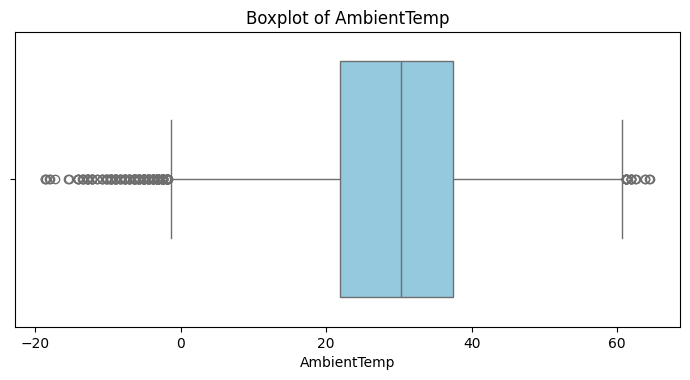

In [118]:
# Boxplot before handling outliers
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(7, 7))
axes = axes.flatten()

for i in range(len(columns_to_handle_outliers)) :
  sns.boxplot(data = df_train_handling_outliers, ax=axes[i], x=columns_to_handle_outliers[i], orient='h', color='skyblue')
  axes[i].set_title(f'Boxplot of {columns_to_handle_outliers[i]}')


# Remove the last subplot if there are fewer features than subplots
if len(columns_to_handle_outliers) < len(axes):
    axes[len(columns_to_handle_outliers)].remove()

plt.tight_layout()

In [119]:
# Remove outliers with IQR method

print(f'The number of rows before filtering out outliers : {len(df_train_handling_outliers)}')

filtered_entries = np.array([True] * len(df_train_handling_outliers))

# Select features with outliers
for col in columns_to_handle_outliers:

    Q1 = df_train_handling_outliers[col].quantile(0.25)
    Q3 = df_train_handling_outliers[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - (IQR * 1.5)
    upper_bound = Q3 + (IQR * 1.5)

    filtered_entries = ((df_train_handling_outliers[col] >= lower_bound) & (df_train_handling_outliers[col] <= upper_bound)) & filtered_entries

df_train_handling_outliers = df_train_handling_outliers[filtered_entries]

print(f'The number of rows after filtering out outliers: {len(df_train_handling_outliers)}')

The number of rows before filtering out outliers : 15783
The number of rows after filtering out outliers: 15601


In [120]:
# # Remove outliers with z-score method

# from scipy import stats

# print(f'The number of rows before filtering out outliers : {len(df_train_handling_outliers)}')

# filtered_entries = np.array([True] * len(df_train_handling_outliers))

# # Select features with outliers
# for col in columns_to_handle_outliers:
#     zscore = abs(stats.zscore(df_train_handling_outliers[col])) # calculate the absolute z-score
#     filtered_entries = (zscore < 3) & filtered_entries # keep z-score values less than absolute 3
    
# df_train_handling_outliers = df_train_handling_outliers[filtered_entries]

# print(f'The number of rows after filtering out outliers: {len(df_train_handling_outliers)}')

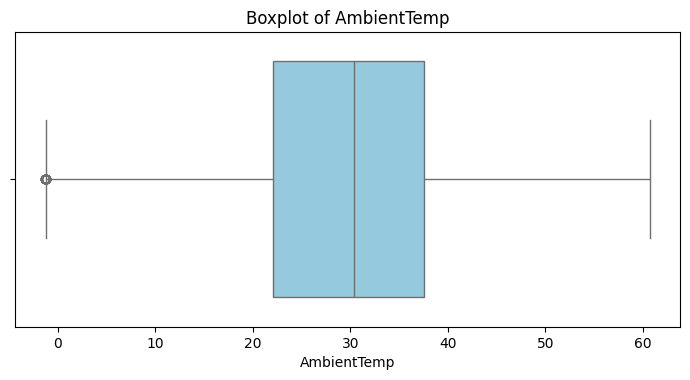

In [121]:
# Boxplot after handling outliers
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(7, 7))
axes = axes.flatten()

for i in range(len(columns_to_handle_outliers)) :
  sns.boxplot(data = df_train_handling_outliers, ax=axes[i], x=columns_to_handle_outliers[i], orient='h', color='skyblue')
  axes[i].set_title(f'Boxplot of {columns_to_handle_outliers[i]}')


# Remove the last subplot if there are fewer features than subplots
if len(columns_to_handle_outliers) < len(axes):
    axes[len(columns_to_handle_outliers)].remove()

plt.tight_layout()

In [122]:
#Split the features and target for train set again
x_train = df_train_handling_outliers.drop(columns='PolyPwr')
y_train = df_train_handling_outliers['PolyPwr']

# Feature Scaling

Scaling will be done to train and test data

In [123]:
x_train

,AmbientTemp,Pressure,Month,Cloud.Ceiling,Humidity,Season_Winter,Season_Summer,Season_Fall,Season_Spring
425,34.77821,1008.2,5,40,18.21289,0,0,0,1
16997,15.55305,1018.4,1,722,73.35815,1,0,0,0
17963,28.46886,1011.3,6,722,39.66064,0,1,0,0
6491,34.91920,1021.6,3,34,39.83154,0,0,0,1
4693,30.30678,857.2,7,722,17.33398,0,1,0,0
...,...,...,...,...,...,...,...,...,...
11284,35.43030,960.1,8,722,25.92163,0,1,0,0
11964,28.32787,984.9,8,60,60.22949,0,1,0,0
5390,42.57805,1019.3,8,722,42.46216,0,1,0,0
860,24.49341,1010.9,8,18,60.41870,0,1,0,0


In [124]:
x_test

,AmbientTemp,Pressure,Month,Cloud.Ceiling,Humidity,Season_Winter,Season_Summer,Season_Fall,Season_Spring
20644,34.77318,805.6,7,24,35.69336,0,1,0,0
20802,58.63594,804.5,8,120,10.96802,0,1,0,0
6836,25.25124,1014.8,11,70,71.70410,0,0,1,0
5865,41.87813,1012.8,11,722,36.25488,0,0,1,0
7628,31.05705,1014.8,5,722,53.44849,0,0,0,1
...,...,...,...,...,...,...,...,...,...
9273,41.25374,960.1,7,722,19.97681,0,1,0,0
5359,43.83942,1013.5,7,722,38.82446,0,1,0,0
12872,24.45816,975.1,8,50,96.44775,0,1,0,0
3288,21.99333,849.9,10,722,27.18506,0,0,1,0


In [125]:
len(x_train.columns)

9

**Additional Reminder About Feature Scalling**

When the original distribution is right-skewed, meaning that the majority of the data is concentrated on the left side with a long tail to the right, it's often more appropriate to use transformations that are less sensitive to extreme values. In this case, Min-Max scaling may be a better choice than Z-score normalization.

Here's a brief explanation:

1. **Min-Max Scaling:**
   - Scales the data to a specific range (e.g., between 0 and 1).
   - Less affected by outliers compared to Z-score normalization.
   - Suitable when the distribution is not normal and skewed.

2. **Z-score Normalization (Standardization):**
   - Centers the data around the mean and scales it by the standard deviation.
   - Can be sensitive to outliers, and right-skewed distributions may have extreme values that influence the scaling.
   - More appropriate when the data is approximately normally distributed.

Given a right-skewed distribution, Min-Max scaling is often a better choice as it allows the preservation of the skewed shape of the distribution and avoids amplifying the impact of outliers. However, the choice may also depend on the specific characteristics of your data and the requirements of your modeling task. If your data has extreme outliers, you might also consider other robust scaling methods.

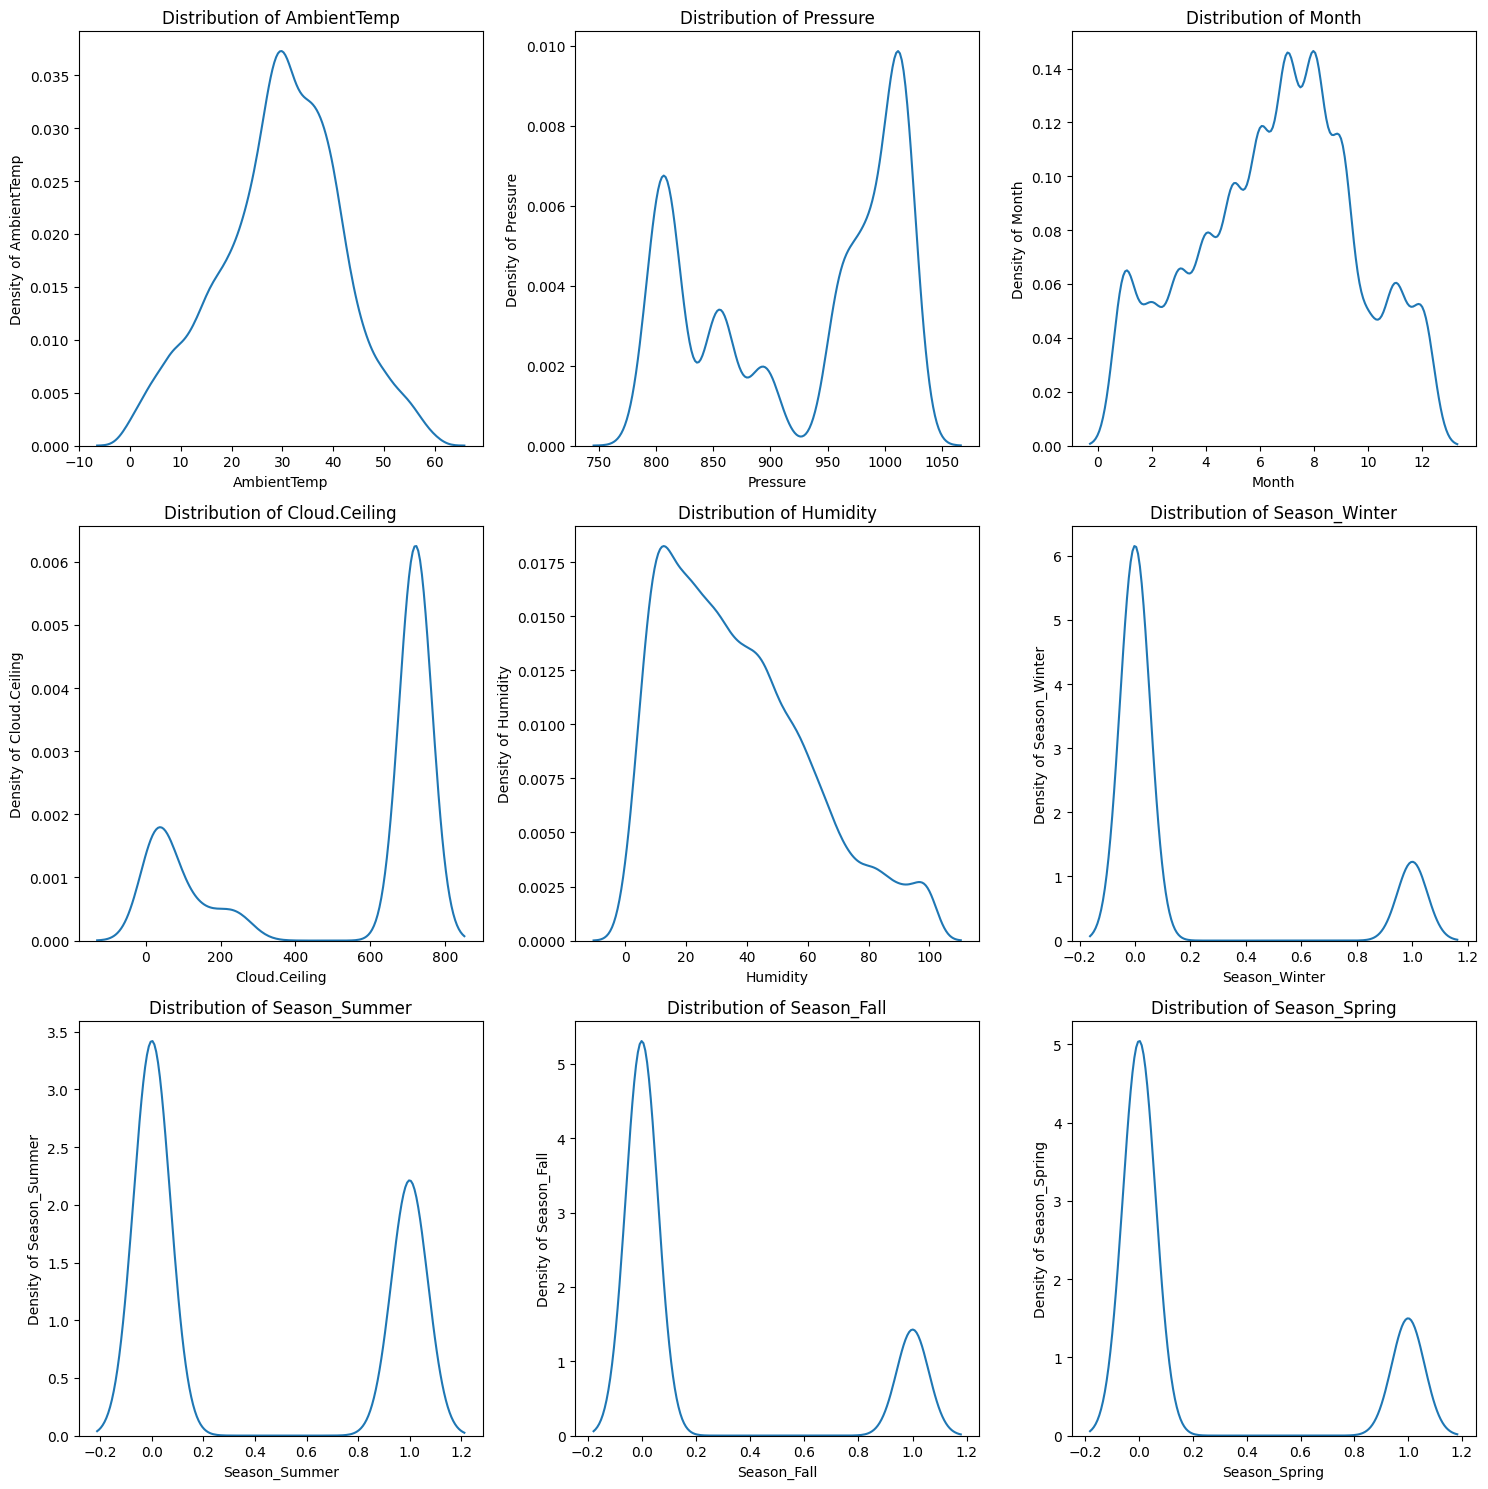

In [126]:
# Checking distribution before scaling
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15,15))
axes = axes.flatten()

for i in range(len(x_train.columns)) :
    sns.kdeplot(data=x_train, ax=axes[i], x=x_train.columns[i])
    axes[i].set_title(f'Distribution of {x_train.columns[i]}')
    axes[i].set_ylabel(f'Density of {x_train.columns[i]}')
    axes[i].set_xlabel(f'{x_train.columns[i]}')

# Remove the last subplot if there are fewer features than subplots
if len(x_train.columns) < len(axes) :
    axes[len(x_train.columns)].remove()

plt.tight_layout()

**Additional thing to remember about scaling multi-modal distribution**

- When dealing with features that have a multi-modal distribution, like the hour feature you mentioned with values [10, 11, 12, 13, 14, 15], scaling might not be as crucial as it is for some other types of data. Scaling is typically more important when working with algorithms that are sensitive to the scale of the input features, such as distance-based algorithms (e.g., k-nearest neighbors) or optimization algorithms (e.g., gradient descent).

- For categorical features like hours of the day, you might consider using techniques like one-hot encoding or ordinal encoding, depending on the nature of the data and the specific machine learning algorithm you plan to use. One-hot encoding represents each category as a binary column, while ordinal encoding assigns integer values based on the order of the categories.

- If you still want to scale the feature for some reason, you can use techniques like Min-Max scaling or Z-score normalization. However, keep in mind that the choice of scaling method might depend on the characteristics of your data and the requirements of your specific machine learning model. Since the hour feature has a limited range, scaling might not have a significant impact on its distribution. Always consider the context and the characteristics of your data when deciding whether or not to scale a particular feature.

In [127]:
x_train.columns

Index(['AmbientTemp', 'Pressure', 'Month', 'Cloud.Ceiling', 'Humidity',
       'Season_Winter', 'Season_Summer', 'Season_Fall', 'Season_Spring'],
      dtype='object')

We will do scaling for non-binary features that we got in encoding process, so we will do this on Humidity, AmbientTemp, Wind.Speed, Visibility, Pressure, and Cloud.Ceiling

In [128]:
#Normalization (MinMaxScaller) & #Standardization (Z-score normalization)
from sklearn.preprocessing import MinMaxScaler, StandardScaler
ms = MinMaxScaler()
ss = StandardScaler()

columns_to_scale = ['Humidity', 'AmbientTemp', 'Pressure', 'Cloud.Ceiling', 'Month']

# Normalize the features (MinMax Scaling)
x_train[columns_to_scale] = ms.fit_transform(x_train[columns_to_scale])
x_test[columns_to_scale] = ms.transform(x_test[columns_to_scale])

# Standardize the normalized features (Z-score Scaling)
x_train[columns_to_scale] = ss.fit_transform(x_train[columns_to_scale])
x_test[columns_to_scale] = ss.transform(x_test[columns_to_scale])

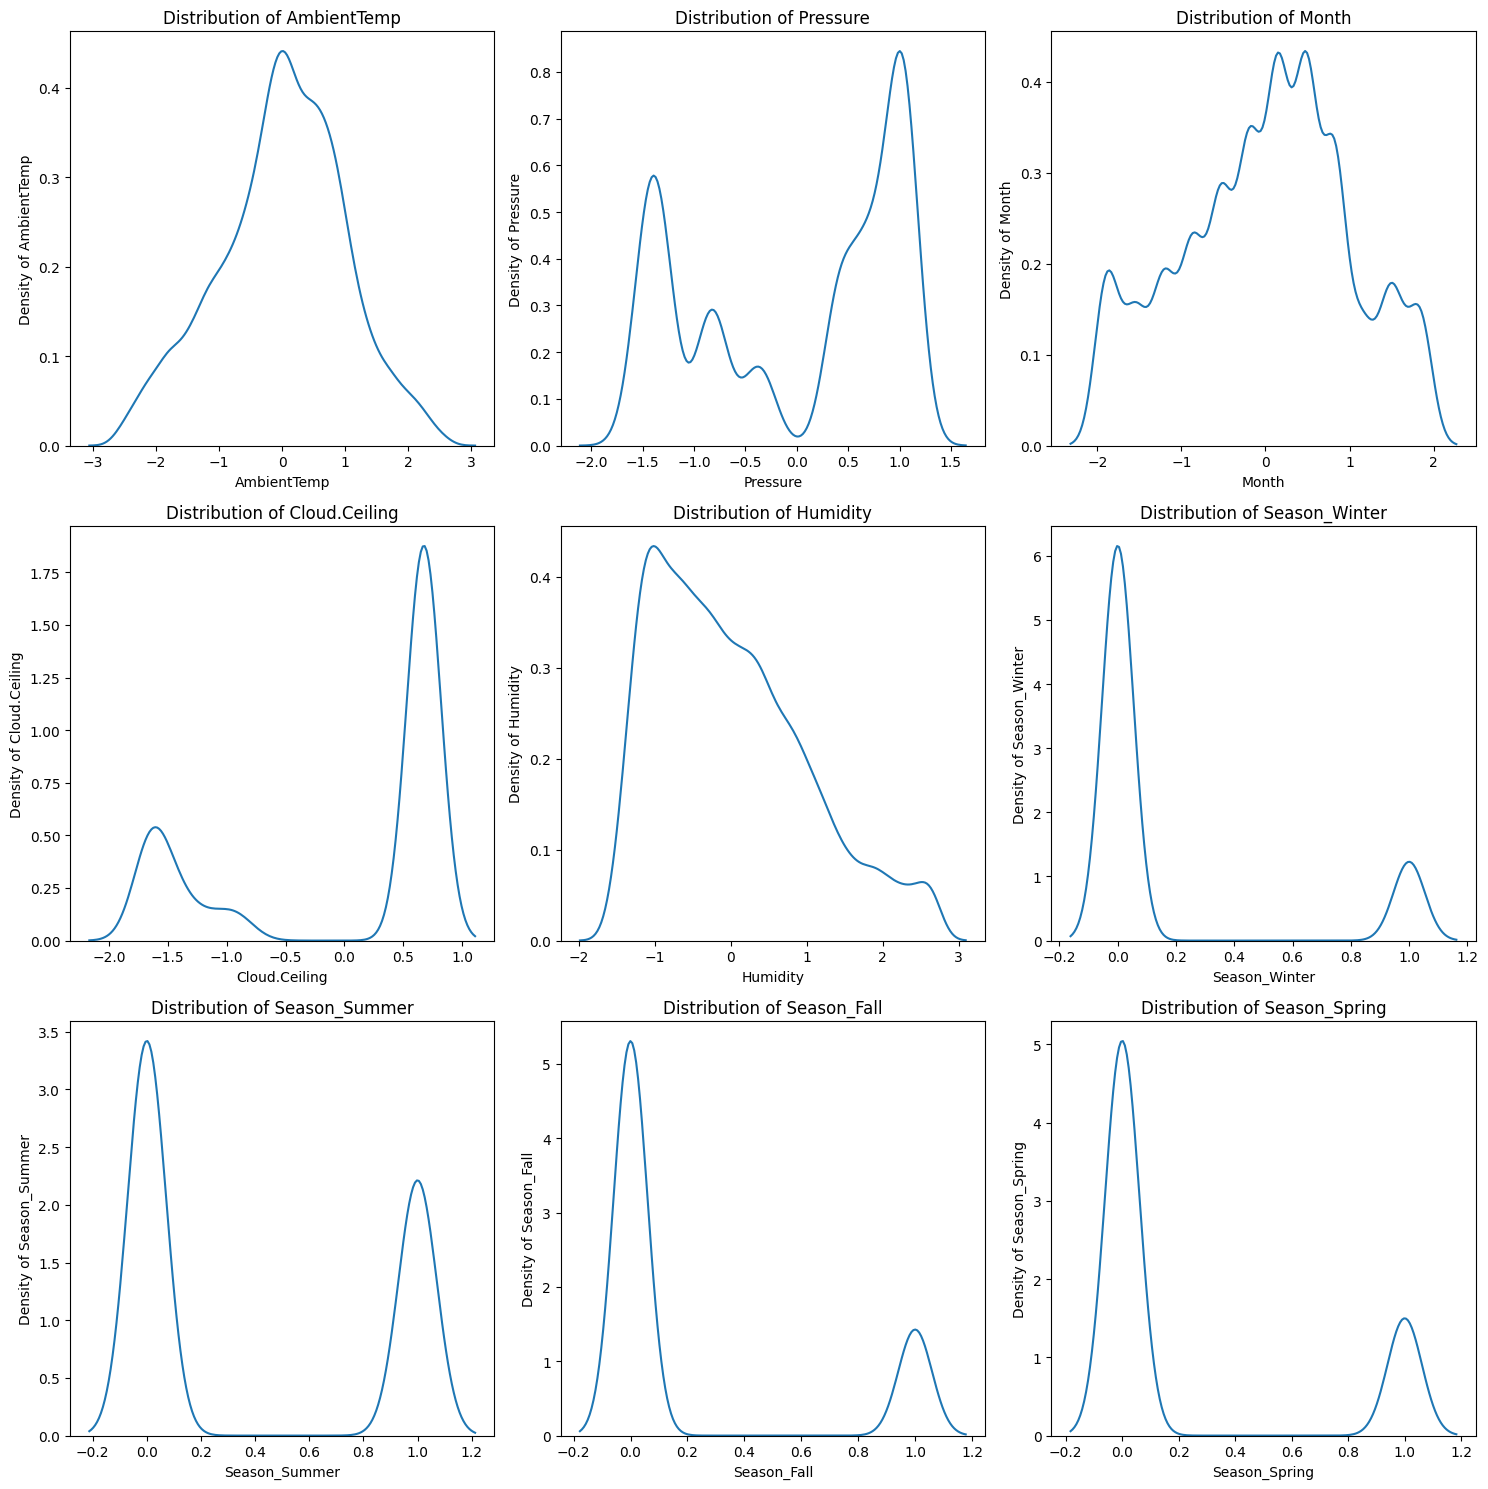

In [129]:
# Checking distribution after scaling
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15,15))
axes = axes.flatten()

for i in range(len(x_train.columns)) :
    sns.kdeplot(data=x_train, ax=axes[i], x=x_train.columns[i])
    axes[i].set_title(f'Distribution of {x_train.columns[i]}')
    axes[i].set_ylabel(f'Density of {x_train.columns[i]}')
    axes[i].set_xlabel(f'{x_train.columns[i]}')

# Remove the last subplot if there are fewer features than subplots
if len(x_train.columns) < len(axes) :
    axes[len(x_train.columns)].remove()

plt.tight_layout()

# Modelling

## Train Regression Models

In [130]:
#Check the amount of training and test data
print(f'Dimension of x_train data : {x_train.shape}')
print(f'Dimension of x_test data : {x_test.shape}')

Dimension of x_train data : (15601, 9)
Dimension of x_test data : (5262, 9)


In [131]:
# Linear Regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [132]:
# Ridge Regression
from sklearn.linear_model import Ridge
ridge = Ridge()
ridge.fit(x_train, y_train)

Ridge()

In [133]:
# Lasso Regression
from sklearn.linear_model import Lasso
lasso = Lasso()
lasso.fit(x_train, y_train)

Lasso()

In [134]:
# Elastic Net Regression
from sklearn.linear_model import ElasticNet
elasticnet = ElasticNet()
elasticnet.fit(x_train, y_train)

ElasticNet()

In [135]:
# Decision Tree
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
dt.fit(x_train, y_train)

DecisionTreeRegressor()

In [136]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()
rf.fit(x_train, y_train)

RandomForestRegressor()

In [137]:
# Support Vector Regression
from sklearn.svm import SVR
svr = SVR()
svr.fit(x_train, y_train)

SVR()

In [138]:
# Boosting : AdaBoost Regression
from sklearn.ensemble import AdaBoostRegressor
ab = AdaBoostRegressor()
ab.fit(x_train, y_train)

AdaBoostRegressor()

In [139]:
# Boosting : XGBoost Regression
from xgboost import XGBRegressor
xg = XGBRegressor()
xg.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [140]:
# Neural Metwork
from sklearn.neural_network import MLPRegressor
nn = MLPRegressor()
nn.fit(x_train, y_train)

MLPRegressor()

## Model Evaluation

In [141]:
#Import metrics score that will be evalueated
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import cross_validate

#Function for model evaluation metrics score
def eval_regression(model):
  y_pred = model.predict(x_test)
  y_pred_train = model.predict(x_train)

  # print('MAE (train): ' + str(mean_absolute_error(y_test, y_pred_train)))
  print('MAE (test): ' + str(mean_absolute_error(y_test, y_pred)))

  # print('RMSE (train): ' + str(mean_squared_error(y_train, y_pred_train, squared=False)))
  print('RMSE (test): ' + str(mean_squared_error(y_test, y_pred, squared=False)))

  # print('MAPE (train): ' + str(mean_absolute_percentage_error(y_train, y_pred_train)))
  print('MAPE (test): ' + str(mean_absolute_percentage_error(y_test, y_pred)))

  # print('R2 (train): ' + str(r2_score(y_train, y_pred_train)))
  print('R2 (test): ' + str(r2_score(y_test, y_pred)))

  #Cross Validation
  score = cross_validate(model, x_train, y_train, cv=5, scoring='r2', return_train_score=True) #scoring change based on what metrics we want to validate (usually choose the main performance metric)
  print('R2 Score (crossval train): '+ str(score['train_score'].mean()))
  print('R2 Score (crossval test): '+ str(score['test_score'].mean()))

In [142]:
#Printing metrics score for all models to compare

#Linear Regression
print('\nEvaluate LinearRegression')
eval_regression(lr)

#Ridge Regressor
print('\nEvaluate RidgeRegression')
eval_regression(ridge)

#Lasso Regressor
print('\nEvaluate LassoRegression')
eval_regression(lasso)

#Elastic Net Regressor
print('\nEvaluate ElasticNetRegression')
eval_regression(elasticnet)

#Decision Tree Regressor
print('\nEvaluate DecisionTreeRegressor')
eval_regression(dt)

#Random Forest Regressor
print('\nEvaluate RandomForestRegressor')
eval_regression(rf)

#Support Vector Regressor
print('\nEvaluate SVR')
eval_regression(svr)

#AdaBoost Regressor
print('\nEvaluate AdaBoostRegressor')
eval_regression(ab)

#XGBoost Regressor
print('\nEvaluate XGBRegressor')
eval_regression(xg)

#MLP Regression
print('\nEvaluate MLPRegressor')
eval_regression(nn)


Evaluate LinearRegression
MAE (test): 3.9994394084948683
RMSE (test): 5.130908542603556
MAPE (test): 0.734655641949125
R2 (test): 0.4833085988453939
R2 Score (crossval train): 0.4652879281267527
R2 Score (crossval test): 0.46463634912072915

Evaluate RidgeRegression
MAE (test): 3.9986718563850245
RMSE (test): 5.129571780422653
MAPE (test): 0.7356889155404442
R2 (test): 0.48357779232054243
R2 Score (crossval train): 0.46530817054203855
R2 Score (crossval test): 0.46453450808147834

Evaluate LassoRegression
MAE (test): 4.631548719766123
RMSE (test): 5.67424917435757
MAPE (test): 0.9081716036958728
R2 (test): 0.3680837941167413
R2 Score (crossval train): 0.3542362099132662
R2 Score (crossval test): 0.354003292694072

Evaluate ElasticNetRegression
MAE (test): 4.69135396342012
RMSE (test): 5.702650328824923
MAPE (test): 0.9323579016851089
R2 (test): 0.3617421392494926


R2 Score (crossval train): 0.34655691408206124
R2 Score (crossval test): 0.3461334163880985

Evaluate DecisionTreeRegressor
MAE (test): 4.16163825731661
RMSE (test): 6.066844049079787
MAPE (test): 0.6333085439882954
R2 (test): 0.27761561505194166
R2 Score (crossval train): 1.0
R2 Score (crossval test): 0.22607672277928442

Evaluate RandomForestRegressor
MAE (test): 3.201642616647663
RMSE (test): 4.477333102695978
MAPE (test): 0.5394396720404069
R2 (test): 0.6065572933683281
R2 Score (crossval train): 0.9422461365760556
R2 Score (crossval test): 0.5825423048734062

Evaluate SVR
MAE (test): 3.2637089682315956
RMSE (test): 4.6490511831077495
MAPE (test): 0.5380173912404295
R2 (test): 0.575799337909814
R2 Score (crossval train): 0.5567705477100617
R2 Score (crossval test): 0.5506693226297894

Evaluate AdaBoostRegressor
MAE (test): 4.559516422097338
RMSE (test): 5.44375961104734
MAPE (test): 0.8988750037974813
R2 (test): 0.4183783485425271
R2 Score (crossval train): 0.4358131754562276
R2 Sc

## Comparison from condition before

- **Evaluate LinearRegression**
  - MAE (test): 384381546.524225
  - RMSE (test): 945221831.907305
  - MAPE (test): 86652247.62650523
  - R2 (test): -1.7543422302307984e+16
  - R2 Score (crossval train): 0.5177048868047509
  - R2 Score (crossval test): 0.5151032534046467

- **Evaluate RidgeRegression**
  - MAE (test): 3.751564913417885
  - RMSE (test): 4.858690379110894
  - MAPE (test): 0.7462236822183446
  - R2 (test): 0.5364620683067971
  - R2 Score (crossval train): 0.5176805200875897
  - R2 Score (crossval test): 0.5151402353083381

- **Evaluate LassoRegression**
  - MAE (test): 4.6882551430698856
  - RMSE (test): 5.688823349184978
  - MAPE (test): 0.9882354878297834
  - R2 (test): 0.3645348676722173
  - R2 Score (crossval train): 0.3380819978816506
  - R2 Score (crossval test): 0.3373951566072594

- **Evaluate ElasticNetRegression**
  - MAE (test): 4.751806881550843
  - RMSE (test): 5.724012791409402
  - MAPE (test): 1.009868685235081
  - R2 (test): 0.35664893990605684
  - R2 Score (crossval train): 0.3314709352581079
  - R2 Score (crossval test): 0.33041433150166594

- **Evaluate DecisionTreeRegressor**
  - MAE (test): 3.7742072885650932
  - RMSE (test): 5.928502717830324
  - MAPE (test): 0.6463845349587861
  - R2 (test): 0.3098605136275516
  - R2 Score (crossval train): 1.0
  - R2 Score (crossval test): 0.2775218231235888

- **Evaluate RandomForestRegressor**
  - MAE (test): 2.85103757187203
  - RMSE (test): 4.200867868025909
  - MAPE (test): 0.565500894347456
  - R2 (test): 0.6534827388917007
  - R2 Score (crossval train): 0.9485050194522723
  - R2 Score (crossval test): 0.6299059314105596

- **Evaluate SVR**
  - MAE (test): 3.730212207160518
  - RMSE (test): 4.893883646480429
  - MAPE (test): 0.7430468581204455
  - R2 (test): 0.5297225993984966
  - R2 Score (crossval train): 0.4875735733247587
  - R2 Score (crossval test): 0.484875932691543

- **Evaluate AdaBoostRegressor**
  - MAE (test): 4.6589784110809465
  - RMSE (test): 5.50396154011463
  - MAPE (test): 0.9947338342436766
  - R2 (test): 0.40516349838272536
  - R2 Score (crossval train): 0.410215649061176
  - R2 Score (crossval test): 0.40062396803006395

- **Evaluate XGBRegressor**
  - MAE (test): 2.9345514307685296
  - RMSE (test): 4.26551875398415
  - MAPE (test): 0.5539045880764762
  - R2 (test): 0.6427349430738472
  - R2 Score (crossval train): 0.8709527944245978
  - R2 Score (crossval test): 0.6179286977843892

## Feature Importance in Linear Models

In [143]:
#Check features
x_train.columns

Index(['AmbientTemp', 'Pressure', 'Month', 'Cloud.Ceiling', 'Humidity',
       'Season_Winter', 'Season_Summer', 'Season_Fall', 'Season_Spring'],
      dtype='object')

In [148]:
# Flatten the coefficient arrays
lr_coef = pd.Series(lr.coef_.flatten())
ridge_coef = pd.Series(ridge.coef_.flatten())
lasso_coef = pd.Series(lasso.coef_.flatten())
elasticnet_coef = pd.Series(elasticnet.coef_.flatten())

# Creating a DataFrame with coefficients
linear_model_coef = pd.DataFrame({'lr_coef': lr_coef,
                                  'ridge_coef': ridge_coef,
                                  'lasso_coef': lasso_coef,
                                  'elasticnet_coef': elasticnet_coef})

# Add feature names to the DataFrame
linear_model_coef['Feature'] = x_train.columns

# Set 'Feature' as the index
linear_model_coef.set_index('Feature', inplace=True)

# Display coef DataFrame
display(linear_model_coef)

,lr_coef,ridge_coef,lasso_coef,elasticnet_coef
Feature,,,,
AmbientTemp,2.956430e+00,2.935343,2.721774,1.994640
Pressure,1.332834e+00,1.329519,0.000000,0.312259
Month,-6.546906e-01,-0.686463,-0.000000,-0.146259
Cloud.Ceiling,1.573344e+00,1.576413,1.027243,1.027210
Humidity,-9.854567e-01,-0.982636,-0.000000,-0.519258
Season_Winter,-2.511745e+13,-2.191621,-0.000000,-0.000000
Season_Summer,-2.511745e+13,0.851463,0.000000,0.000000
Season_Fall,-2.511745e+13,-0.849184,-0.000000,-0.000000
Season_Spring,-2.511745e+13,2.189342,0.000000,0.000000


# Summary of Models Generated by Various Machine Learning Algorithms

Experiment was conducted on the models below :

1. Linear Regression (with regularization : Ridge, Lasso, and Elastic Net)
2. Decision Tree Regression
3. Random Forest Regression
4. Support Vector Regression
5. Gradient Boosting Regression (AdaBoost and XGBoost)
6. Multi-Layer Perceptron (MLP) Regression

From all of the models, the best results were obtained by:

- **Random Forest Regression**
- **XGBoost Regression**

Therefore, hyperparameter tuning can be applied to these two models to slightly improve their results (for other models that also have decent performance, experiments will be conducted if there is time and additional resources available).

## Feature Importances from Regression Models

In [145]:
#Function for model feature importance score
def show_feature_importance(model):
    feat_importances = pd.Series(model.feature_importances_, index=x.columns)
    ax = feat_importances.nlargest(25).plot(kind='barh', figsize=(10, 8))
    ax.invert_yaxis()

    plt.xlabel('Score')
    plt.ylabel('Feature')
    plt.title('Feature importance score')

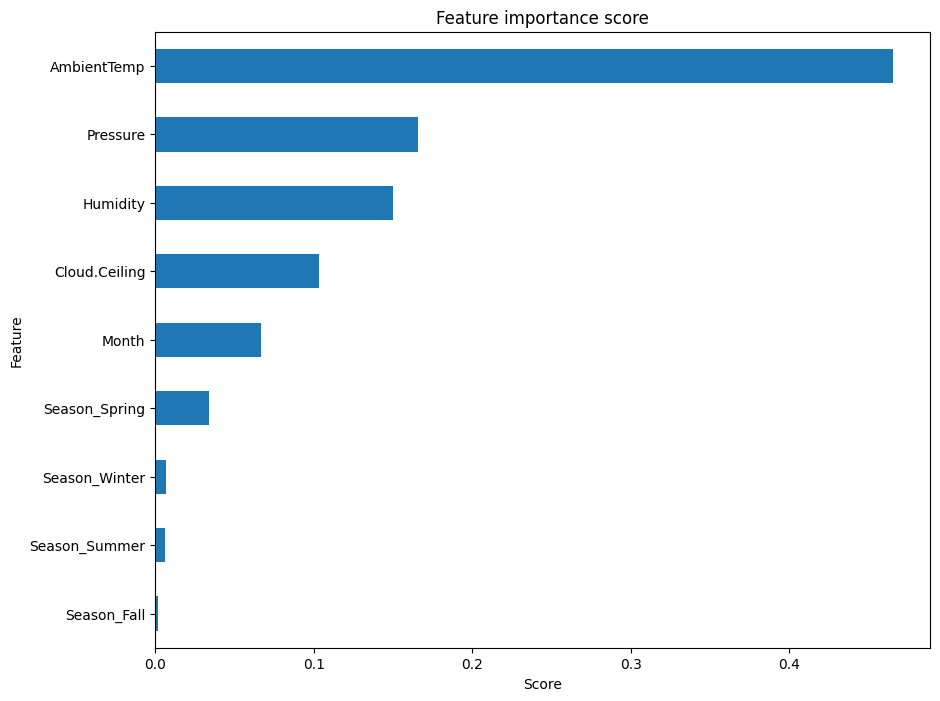

In [146]:
# Feature importance in random forest
show_feature_importance(rf)

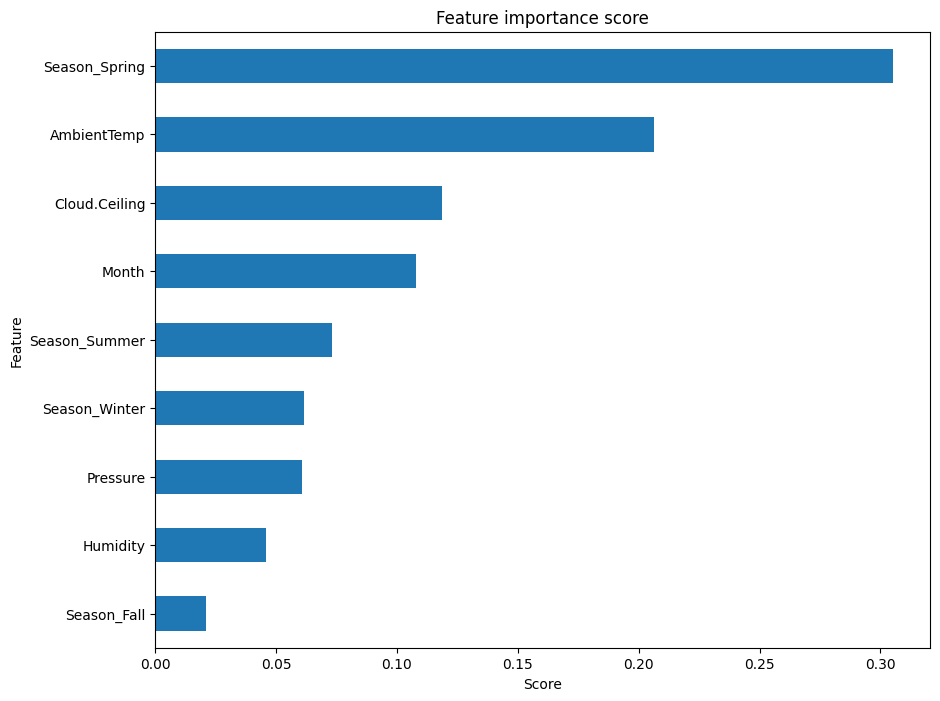

In [147]:
# Feature importance in XGB
show_feature_importance(xg)

## Hyperparameter Tuning

In [77]:
#Function for best hyperparameters found during the tuning process
def show_best_hyperparameter(model):
    print(model.best_estimator_.get_params())

### Hyperparameter Tuning For Random Forest Regression

<b>Commonly tuned hyperparameters in Random Forest:</b> (<a href='https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html'>Sklearn Random Forest Documentation</a>)

- n_estimators: the number of trees to be built in the forest.
- max_samples: the maximum number of samples to be drawn from the total training set for building each tree (after the bootstrap process).

The remaining hyperparameters are the same as in Decision Trees:

- criterion: the method used to measure impurity in features (gini, entropy). This is for classification; for regression, it's different. It determines which feature becomes the root/node (squared_error, poisson).
- max_depth: the maximum depth of each tree to prevent overfitting.
- min_sample_split: the minimum number of samples required at a node to create a new leaf (to avoid having too few samples, which can lead to overfitting).
- min_sample_leaf: the minimum number of samples required in a leaf for the leaf to be formed (to avoid having too few samples, which can lead to overfitting).
- ccp_alpha: if the cost/error of a leaf/subtree is greater than ccp_alpha, that subtree will be pruned, minimizing the error/variance of the model.

In [78]:
# Hyperparameter Tuning for random forest
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

#Initiate hyperparameters used and their values
n_estimators = [int(x) for x in np.linspace(1, 200, 50)]
criterion = ['squared_error', 'poisson']
max_depth = [int(x) for x in np.linspace(50, 180, 5)]
min_samples_split = [2, 5, 10, 50]
min_samples_leaf = [1, 2, 5, 8, 20, 30] 

#Collecting all hyperparameters into a single dictionary
hyperparameters = dict(n_estimators=n_estimators, 
                       criterion=criterion, 
                       max_depth=max_depth,
                       min_samples_split=min_samples_split,
                       min_samples_leaf=min_samples_leaf)

#Initiate tuned model
rf = RandomForestRegressor()
# rf_tuned = GridSearchCV(dt, hyperparameters, cv=5, scoring='r2')
rf_tuned = RandomizedSearchCV(rf, hyperparameters, scoring='r2', cv=5, error_score='raise')
rf_tuned.fit(x_train, y_train)

#Tuned model evaluation
eval_regression(rf_tuned)

MAE (test): 2.8436943639319505
RMSE (test): 4.209792375265601
MAPE (test): 0.5632686247253577
R2 (test): 0.652008862150371
R2 Score (crossval train): 0.8931673590139722
R2 Score (crossval test): 0.6325874691103577


In [79]:
# Best hyperparameter in random forest
show_best_hyperparameter(rf_tuned)

{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'poisson', 'max_depth': 180, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 'min_samples_split': 5, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 82, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}


In [80]:
# Retrieving the best hyperparameters for random forest (similar to show_best_hyperparameter code before, but only shows the ones that we used)
best_params = rf_tuned.best_params_
best_params

{'n_estimators': 82,
 'min_samples_split': 5,
 'min_samples_leaf': 2,
 'max_depth': 180,
 'criterion': 'poisson'}

In [81]:
# #Learning curve for hyperparameters

# # Hyperparameter that will be tested and their values (can be found in best hyperparameter before or experiment with others)
# # param_values = [int(x) for x in np.linspace(50, 180, 5)] # n_estimators
# # param_values = [int(x) for x in np.linspace(50, 180, 5)] # max_depth
# # param_values = [int(x) for x in np.linspace(2, 10, 2)] # min_samples_split
# param_values = [int(x) for x in np.linspace(2, 10, 2)] # min_samples_leaf

# train_scores = []
# test_scores = []

# for i in param_values:
#     model = RandomForestRegressor(min_samples_leaf=i) # Change based on what hyperparameter that we used
#     model.fit(x_train, y_train)

#     # eval on train
#     y_pred_train_proba = model.predict_proba(x_train)
#     train_r2 = r2_score(y_train, y_pred_train_proba[:,1])
#     train_scores.append(train_r2)

#     # eval on test
#     y_pred_proba = model.predict_proba(x_test)
#     test_r2 = r2_score(y_test, y_pred_proba[:,1])
#     test_scores.append(test_r2)

#     print('Param value: ' + str(i) + '; train: ' + str(train_r2) + '; test: '+ str(test_r2))

# plt.title('Learning Curve | Hyperparameter : min_sample_leaf | Random Forest') # Change based on what hyperparameter that we used
# plt.ylabel('R2 Score')
# plt.xlabel('min_sample_leaf') # Change based on what hyperparameter that we used
# plt.plot(param_values, train_scores, label='Train')
# plt.plot(param_values, test_scores, label='Test')
# plt.legend()
# plt.show()

### Hyperparameter Tuning For XGBoost Regression

<b>Commonly tuned hyperparameters in XGBoost:</b>  (<a href='https://xgboost.readthedocs.io/en/latest/parameter.html'>XGBoost Documentation</a>)

- <b>Tree architecture-related:</b>
    - max_depth: the maximum depth of the tree to prevent overfitting.
    - min_child_weight: the minimum weight (or the number of samples if the total weight equals 1) a node should have to create a new leaf (to avoid having too few, causing overfitting).
    - gamma: the minimum loss/error reduction required to make a new leaf.
    - tree_method: the method XGBoost uses to build a tree. The algorithm we are learning is tree_method = exact. Other references can be found <a href='https://xgboost.readthedocs.io/en/latest/treemethod.html'>here</a>.

- <b>Boosting process subsampling:</b> Instead of using the entire training data in each iteration, we can use a sample in each iteration.
    - subsample: how much of the row samples to be used for sampling at each step. 1 for all rows.
    - colsample_bytree: how many features to be used. 1 for all features.

- <b>Control learning rate:</b>
    - eta: the step size for updating the feature weight in XGBoost, value range: 0-1. Smaller eta provides more fine-grained corrections but requires more boosting iterations.
        - In sklearn, the hyperparameter name is learning_rate.

- <b>Regularization in XGBoost:</b>
    - lambda: the regularization term on L2 norm.
    - alpha: the regularization term on L1 norm.

- <b>Learning task in XGBoost:</b>
    - objective: the objective function used, such as calculating error in regression.
    - eval_metric: evaluation metrics used on the validation data (e.g., rmse, mae, auc).
    - seed: random state.

- <b>Others:</b>
    - scale_pos_weight: if the data is imbalanced, this parameter is used to adjust the weight of each label.
    
- <b>Other parameters for model checking and debugging:</b>
    - verbose: to display detailed log information during the model training. 0: no messages; 1: display warnings only; 2: display info (deprecated examples); 3: debug: detailed training information for the model.

In [86]:
#Hyperparameter tuning for xgb
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

#Initiate hyperparameters used and their values
max_depth = [int(x) for x in np.linspace(5, 20, 11)]
min_child_weight = [int(x) for x in np.linspace(1, 20, 11)]
gamma = [float(x) for x in np.linspace(0, 3, num = 11)]
tree_method = ['auto', 'exact', 'approx']

colsample_bytree = [float(x) for x in np.linspace(0, 1, 11)]
eta = [float(x) for x in np.linspace(0, 1, num = 100)]

# lambda = [float(x) for x in np.linspace(0, 1, 11)]
alpha = [float(x) for x in np.linspace(0, 1, 11)]

#Collecting all hyperparameters into a single dictionary
hyperparameters = dict(max_depth=max_depth, 
                       min_child_weight=min_child_weight, 
                       gamma=gamma,
                       tree_method=tree_method,
                       colsample_bytree=colsample_bytree,
                       eta=eta,
                       alpha=alpha)

#Initiate tuned model
xg = XGBRegressor()
# xg_tuned = GridSearchCV(xg, hyperparameters, cv=5, scoring='r2')
xg_tuned = RandomizedSearchCV(xg, hyperparameters, scoring='r2', cv=5, error_score='raise')
xg_tuned.fit(x_train,y_train)

# Evaluation
eval_regression(xg_tuned)

MAE (test): 2.858064295764701
RMSE (test): 4.218963022847517
MAPE (test): 0.535744854162412
R2 (test): 0.6504910770512162
R2 Score (crossval train): 0.7981895681127092
R2 Score (crossval test): 0.6284883788517422


In [87]:
# Best hyperparameter in xgb
show_best_hyperparameter(xg_tuned)

{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'gamma': 1.2, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 9, 'max_leaves': None, 'min_child_weight': 6, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': None, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': None, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': 'approx', 'validate_parameters': None, 'verbosity': None, 'eta': 0.19191919191919193, 'alpha': 0.8}


In [88]:
# Retrieving the best hyperparameters for xgb (similar to show_best_hyperparameter code before, but only shows the ones that we used)
best_params = xg_tuned.best_params_
best_params

{'tree_method': 'approx',
 'min_child_weight': 6,
 'max_depth': 9,
 'gamma': 1.2,
 'eta': 0.19191919191919193,
 'colsample_bytree': 0.8,
 'alpha': 0.8}

In [89]:
# #Learning curve for hyperparameters

# # Hyperparameter that will be tested and their values (can be found in best hyperparameter before or experiment with others)
# # param_values = [int(x) for x in np.linspace(5, 20, 11)] #max_depth
# # param_values = [int(x) for x in np.linspace(1, 20, 11)] #min_child_weight
# # param_values = [float(x) for x in np.linspace(0, 3, num = 11)] #gamma
# # param_values = ['auto', 'exact', 'approx'] #tree_method
# # param_values = [float(x) for x in np.linspace(0, 1, 11)] #colsample_bytree
# # param_values = [float(x) for x in np.linspace(0, 1, 100)] #eta
# # param_values = [float(x) for x in np.linspace(0, 1, 11)] #lambda
# param_values = [float(x) for x in np.linspace(0, 1, 11)] #alpha

# train_scores = []
# test_scores = []

# for i in param_values:
#     model = XGBRegressor(alpha=i) # Change based on what hyperparameter that we used
#     model.fit(x_train, y_train)

#     # eval on train
#     y_pred_train_proba = model.predict_proba(x_train)
#     train_r2 = r2_score(y_train, y_pred_train_proba[:,1])
#     train_scores.append(train_r2)

#     # eval on test
#     y_pred_proba = model.predict_proba(x_test)
#     test_r2 = r2_score(y_test, y_pred_proba[:,1])
#     test_scores.append(test_r2)

#     print('Param value: ' + str(i) + '; train: ' + str(train_r2) + '; test: '+ str(test_r2))

# plt.title('Learning Curve | Hyperparameter : alpha | XGB') # Change based on what hyperparameter that we used
# plt.ylabel('AUC')
# plt.xlabel('alpha') # Change based on what hyperparameter that we used
# plt.plot(param_values, train_scores, label='Train')
# plt.plot(param_values, test_scores, label='Test')
# plt.legend()
# plt.show()

# Comparison of Results Before and After Hyperparameter Tuning

<b>Evaluate RandomForestRegressor</b>

A. Before Hyperparameter Tuning
* MAE (test): 2.85103757187203
* RMSE (test): 4.200867868025909
* MAPE (test): 0.565500894347456
* R2 (test): 0.6534827388917007
* R2 Score (crossval train): 0.9485050194522723
* R2 Score (crossval test): 0.6299059314105596

B. After Hyperparameter Tuning
* MAE (test): 2.8436943639319505
* RMSE (test): 4.209792375265601
* MAPE (test): 0.5632686247253577
* R2 (test): 0.652008862150371
* R2 Score (crossval train): 0.8931673590139722
* R2 Score (crossval test): 0.6325874691103577

<b>Evaluate XGBRegressor</b>

A. Before Hyperparameter Tuning
* MAE (test): 2.9345514307685296
* RMSE (test): 4.26551875398415
* MAPE (test): 0.5539045880764762
* R2 (test): 0.6427349430738472
* R2 Score (crossval train): 0.8709527944245978
* R2 Score (crossval test): 0.6179286977843892

B. After Hyperparameter Tuning
* MAE (test): 2.858064295764701
* RMSE (test): 4.218963022847517
* MAPE (test): 0.535744854162412
* R2 (test): 0.6504910770512162
* R2 Score (crossval train): 0.7981895681127092
* R2 Score (crossval test): 0.6284883788517422

It does increse the R2 score even just a little but further tuning obviously still needs to be done, and we also have to experiment with other combination of features in training